# ⚠️ Memory-Optimized Version

**This notebook has been optimized for systems with limited RAM** 

Instead of loading all tracking data at once (~10+ GB), this version:
- ✅ Uses **Polars** for efficient data loading
- ✅ Loads matches **on-demand** only when needed
- ✅ Processes data in **batches** for aggregate statistics
- ✅ Automatically **frees memory** after each operation

**Key differences from the original:**
- No global `tracking` DataFrame - matches are loaded individually
- Helper functions: `load_match_polars(match_id)` and `load_match_pandas(match_id)`
- All analysis produces the **same results** as the original notebook

**To use this notebook:**
1. Run cells in order from top to bottom
2. Each section loads only the data it needs
3. If you encounter a memory error, restart the kernel and re-run from the beginning

Let's get started! 🚀


# Module 1 — Tracking Data Fundamentals (SkillCorner)  
**Goal:** Load multi-match tracking, normalise orientation (left→right), resample to a common Hz, and smooth noise.  
By the end you'll have a clean per-frame, per-player table you can use for shape features and clustering.


## 0. Setup & Configuration
Update the paths below to your local folders. This notebook assumes:
- `matches.parquet` lists available matches (`id`, `home_team`, `away_team`, ...)
- A `tracking/` folder with one JSON per match: `<match_id>.json`

> Tip: Keep raw data read-only and write any processed files to a separate folder.


## 📖 Quick Reference

**Load a single match:**
```python
match_data = load_match_pandas(match_id)  # Returns Pandas DataFrame
# or
match_data_pl = load_match_polars(match_id)  # Returns Polars DataFrame (faster, less memory)
```

**Free memory when done:**
```python
del match_data
gc.collect()
```

**Process multiple matches in batches:**
```python
for match_id in df_matches["id"].values[:10]:  # First 10 matches
    data = load_match_pandas(match_id)
    # ... do analysis ...
    del data
    gc.collect()
```


In [1]:
#Install packages

#Basic imports
from pathlib import Path
import json
import numpy as np
import pandas as pd
import polars as pl

#Stats
import seaborn as sns
from sklearn.cluster import KMeans

#Plotting
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.spatial import ConvexHull, Voronoi

# Memory management
import gc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

#Data directory
DATA_DIR = Path.cwd().parents[0]


In [2]:
# --- Paths (EDIT ME) ---
DATA_DIR = Path(DATA_DIR)
BASE_DIR = DATA_DIR / 'RealMadrid'
MATCHES_PATH = BASE_DIR / 'matches.parquet'
TRACKING_DIR = BASE_DIR / 'tracking'
TRACKING_DIR_PARQUET = BASE_DIR / 'tracking_parquets'

# Output
PROCESSED_DIR = BASE_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

# Get list of available tracking parquet files
parquet_files = sorted(list(TRACKING_DIR_PARQUET.glob("*.parquet")))

# Pitch config (meters)
PITCH_LENGTH = 105.0
PITCH_WIDTH  = 68.0

# Target frequency (Hz)
TARGET_HZ = 10.0
DEFAULT_FPS = 10.0


## 1. Load Matches List
We start by reading the matches table and selecting the subset we want to process.


In [3]:
df_matches = pd.read_parquet(MATCHES_PATH)
df_matches = df_matches.sort_values('date_time').reset_index(drop=True)
df_matches.head()


,id,date_time,home_team,away_team,status,competition_id,season_id,competition_edition_id
0,1021404,2023-08-12T19:30:00Z,"{'id': 273, 'short_name': 'Athletic Bilbao'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
1,1036527,2023-08-19T17:30:00Z,"{'id': 274, 'short_name': 'UD Almería'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
2,1048195,2023-08-25T19:30:00Z,"{'id': 285, 'short_name': 'Celta Vigo'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
3,1064327,2023-09-02T14:15:00Z,"{'id': 262, 'short_name': 'Real Madrid'}","{'id': 268, 'short_name': 'Getafe CF'}",closed,4,28,546
4,1096879,2023-09-17T19:00:00Z,"{'id': 262, 'short_name': 'Real Madrid'}","{'id': 282, 'short_name': 'Real Sociedad'}",closed,4,28,546


In [4]:
df_matches.shape

(99, 8)

## 2. Tracking Reader (per match)
Each tracking JSON is a list of frames.


In [28]:
#Example tracking files
example_match_id = df_matches.loc[0, 'id']
with open(TRACKING_DIR / f"{example_match_id}.json", "r") as f:
    example_tracking_data = json.load(f)

example_tracking_data[1000:1001]  # show frames 1000

[{'frame': 1000,
  'timestamp': '00:01:39.00',
  'period': 1,
  'ball_data': {'x': 13.82, 'y': 29.81, 'z': 0.1, 'is_detected': True},
  'possession': {'player_id': None, 'group': 'home team'},
  'image_corners_projection': {'x_top_left': -13.04,
   'y_top_left': 39.0,
   'x_bottom_left': -6.28,
   'y_bottom_left': -17.74,
   'x_bottom_right': 13.64,
   'y_bottom_right': -19.58,
   'x_top_right': 30.69,
   'y_top_right': 39.0},
  'player_data': [{'x': -37.46,
    'y': 4.46,
    'player_id': 13899,
    'is_detected': False},
   {'x': -11.41, 'y': 6.87, 'player_id': 13903, 'is_detected': False},
   {'x': -7.4, 'y': 18.71, 'player_id': 32276, 'is_detected': True},
   {'x': -10.33, 'y': -9.18, 'player_id': 8259, 'is_detected': False},
   {'x': -6.74, 'y': 26.39, 'player_id': 4463, 'is_detected': True},
   {'x': 3.97, 'y': 23.97, 'player_id': 11692, 'is_detected': True},
   {'x': -4.38, 'y': 6.15, 'player_id': 25739, 'is_detected': True},
   {'x': 10.63, 'y': 20.23, 'player_id': 533061, 'is_

## In the script convert_tracking_json_to_parquets.py we flatten the tracking data into tidy tables with one row per `(frame, player_id)` plus ball rows for all matches. 

Run that script to continue:

**In the terminal of your IDE, run:**

```bash
python3 convert_tracking_json_to_parquets.py


In [29]:
len(df_matches['id'].unique()), len(list(TRACKING_DIR_PARQUET.glob("*.parquet")))


(99, 99)

In [30]:
some_match_id= 1506182
temp = pd.read_parquet(TRACKING_DIR_PARQUET / f"{some_match_id}.parquet")
print(len(temp), len(temp.drop_duplicates()))

991461 991461


### 📊 Memory-Efficient Data Loading Strategy

**Important:** This notebook uses **on-demand loading** to work with limited RAM.

Instead of loading all tracking data at once (which would consume ~10+ GB), we:
- ✅ Load individual matches only when needed using **Polars** for efficiency
- ✅ Convert to Pandas only for analysis/visualization
- ✅ Use garbage collection to free memory after processing
- ✅ Process matches in batches for aggregate statistics

**Helper functions available:**
- `load_match_polars(match_id)` → Returns Polars DataFrame
- `load_match_pandas(match_id)` → Returns Pandas DataFrame (ready for analysis)


In [5]:
# Get list of parquet files for processing
parquet_files = sorted(list(TRACKING_DIR_PARQUET.glob("*.parquet")))
print(f"✅ Found {len(parquet_files)} parquet files to process")
print(f"   These will be loaded on-demand in batches to save RAM")

# Helper function to load one match with Polars
def load_match_polars(match_id: int) -> pl.DataFrame:
    """Load a single match using Polars for memory efficiency."""
    file_path = TRACKING_DIR_PARQUET / f"{match_id}.parquet"
    if not file_path.exists():
        raise FileNotFoundError(f"No parquet for match {match_id}")
    return pl.read_parquet(file_path)

# Helper function to load one match and convert to pandas
def load_match_pandas(match_id: int) -> pd.DataFrame:
    """Load a single match and convert to pandas for compatibility."""
    return load_match_polars(match_id).to_pandas()


✅ Found 99 parquet files to process
   These will be loaded on-demand in batches to save RAM


In [8]:
# Preview one match to understand the data structure
sample_match_id = df_matches.loc[0, 'id']
sample_tracking = load_match_pandas(sample_match_id)
print(f"Sample tracking data for match {sample_match_id}:")
print(f"  Shape: {sample_tracking.shape}")
print(f"  Columns: {sample_tracking.columns.tolist()}")
print(f"\nFirst few rows:")
sample_tracking.head()


Sample tracking data for match 1021404:
  Shape: (1051215, 9)
  Columns: ['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected', 'is_ball', 'x', 'y']

First few rows:


,match_id,time,frame,period,player_id,is_detected,is_ball,x,y
0,1021404,00:00:00.00,10,1,13899,False,False,-37.51,0.97
1,1021404,00:00:00.00,10,1,13903,False,False,-21.31,-4.37
2,1021404,00:00:00.00,10,1,32276,False,False,-20.57,6.35
3,1021404,00:00:00.00,10,1,8259,False,False,-6.86,-16.78
4,1021404,00:00:00.00,10,1,4463,False,False,-18.92,11.42


# 4. Data Quality Analysis 

**Objective:** Check the completeness of tracking data across all matches.

We want to verify that each frame has:
- ✅ **22 players** (11 per team)
- ✅ **1 ball**

This helps us understand:
- Data reliability
- Potential tracking errors
- Frames that may need special handling

**Method:** Process matches in batches to avoid loading everything into memory at once.


In [8]:
# Quick completeness check on one sample match
# This gives us an idea of what to expect before running the full analysis

print(f"🔍 Quick check on sample match {sample_match_id}:")
print(f"   Total rows: {len(sample_tracking):,}")

# Check this match's frame completeness
sample_frame_check = (
    sample_tracking.groupby(["match_id", "frame"])
    .agg(
        n_players=("player_id", lambda x: x[~(x == -1)].nunique()),  # unique non-ball players
        n_balls=("is_ball", "sum")                                   # count ball rows
    )
    .reset_index()
)

# Identify problematic frames in this sample
sample_problems = sample_frame_check[(sample_frame_check["n_players"] < 22) | (sample_frame_check["n_balls"] < 1)]

print(f"\n   Total frames: {len(sample_frame_check):,}")
print(f"   Frames with issues: {len(sample_problems):,}")
print(f"   Success rate: {((len(sample_frame_check) - len(sample_problems)) / len(sample_frame_check) * 100):.2f}%")

if len(sample_problems) > 0:
    print(f"\n   Sample problematic frames:")
    print(sample_problems.head(5))
else:
    print("\n   ✅ Perfect! All frames in this match have 22 players and 1 ball")

# Clean up
del sample_frame_check, sample_problems
gc.collect()

print("\n💡 Now let's run the full analysis across all matches...")


🔍 Quick check on sample match 1021404:
   Total rows: 1,051,215

   Total frames: 45,705
   Frames with issues: 0
   Success rate: 100.00%

   ✅ Perfect! All frames in this match have 22 players and 1 ball

💡 Now let's run the full analysis across all matches...

   Total frames: 45,705
   Frames with issues: 0
   Success rate: 100.00%

   ✅ Perfect! All frames in this match have 22 players and 1 ball

💡 Now let's run the full analysis across all matches...


In [18]:
# 🔄 Full Data Quality Analysis: Process all matches in batches
# This analyzes frame completeness across the entire dataset without loading everything at once

print("=" * 70)
print("DATA QUALITY ANALYSIS - Processing all matches in batches")
print("=" * 70)

# Initialize results - collect aggregated frame-level statistics
all_frame_stats = []  # Will store summary: frames per missing_players count
all_issues_sample = []  # Will store sample of problematic frames for detailed analysis
batch_size = 10
total_batches = (len(parquet_files) + batch_size - 1) // batch_size

print(f"\n📊 Processing {len(parquet_files)} matches in {total_batches} batches of {batch_size}")
print("-" * 70)

for i in range(0, len(parquet_files), batch_size):
    batch_files = parquet_files[i:i+batch_size]
    batch_end = min(i + batch_size, len(parquet_files))
    batch_num = i // batch_size + 1
    
    print(f"\n🔄 Batch {batch_num}/{total_batches}: Processing matches {i+1}-{batch_end}...", end=" ", flush=True)
    
    try:
        # Load this batch using Polars for efficiency
        batch_dfs = []
        for file_path in batch_files:
            df_pl = pl.read_parquet(file_path)
            batch_dfs.append(df_pl.to_pandas())
        
        # Concatenate batch
        batch_tracking = pd.concat(batch_dfs, ignore_index=True)
        del batch_dfs
        
        # Analyze frame completeness for this batch
        frame_counts = (
            batch_tracking
            .groupby(["match_id", "frame"])
            .agg(
                n_players=("is_ball", lambda x: (~x).sum()),
                n_balls=("is_ball", "sum")
            )
            .reset_index()
        )
        
        # Calculate missing
        frame_counts["missing_players"] = 22 - frame_counts["n_players"]
        frame_counts["missing_ball"] = 1 - frame_counts["n_balls"]
        
        # Find problematic frames
        batch_issues = frame_counts[
            (frame_counts["missing_players"] > 0) | (frame_counts["missing_ball"] > 0)
        ].copy()
        
        # Store distribution of missing_players (for histogram later)
        # Count how many frames have 0, 1, 2, ... missing players
        missing_dist = frame_counts["missing_players"].value_counts().to_dict()
        all_frame_stats.append(missing_dist)
        
        # Store sample of actual problematic frames (for mean calculations)
        if len(batch_issues) > 0:
            # Keep all issues from this batch (we'll sample later if needed)
            all_issues_sample.append(batch_issues[["match_id", "frame", "missing_players", "missing_ball"]])
        
        # Report batch summary
        batch_frames = len(frame_counts)
        batch_problem_count = len(batch_issues)
        batch_success = ((batch_frames - batch_problem_count) / batch_frames * 100) if batch_frames > 0 else 100
        
        print(f"✓ Frames: {batch_frames:,} | Issues: {batch_problem_count:,} | Success: {batch_success:.2f}%")
        
        # Clean up
        del batch_tracking, frame_counts, batch_issues
        gc.collect()
        
    except Exception as e:
        print(f"\n   ❌ Error: {e}")
        import traceback
        traceback.print_exc()
        continue

# Aggregate frame statistics across all batches
# Combine the distribution data
frame_check = {}
for dist in all_frame_stats:
    for missing_count, num_frames in dist.items():
        frame_check[missing_count] = frame_check.get(missing_count, 0) + num_frames

# Combine all problematic frames
if all_issues_sample:
    issues = pd.concat(all_issues_sample, ignore_index=True)
else:
    issues = pd.DataFrame(columns=["match_id", "frame", "missing_players", "missing_ball"])

# Calculate overall statistics
total_frames = sum(frame_check.values())
total_issues = len(issues)
success_rate = ((total_frames - total_issues) / total_frames * 100) if total_frames > 0 else 100

# Final summary
print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE!")
print("=" * 70)
print(f"\n📊 Overall Statistics:")
print(f"   Total frames analyzed: {total_frames:,}")
print(f"   Frames with issues: {total_issues:,}")
print(f"   Perfect frames: {total_frames - total_issues:,}")
print(f"   Overall success rate: {success_rate:.2f}%")


DATA QUALITY ANALYSIS - Processing all matches in batches

📊 Processing 99 matches in 10 batches of 10
----------------------------------------------------------------------

🔄 Batch 1/10: Processing matches 1-10... ✓ Frames: 459,204 | Issues: 1,603 | Success: 99.65%

🔄 Batch 2/10: Processing matches 11-20... ✓ Frames: 459,204 | Issues: 1,603 | Success: 99.65%

🔄 Batch 2/10: Processing matches 11-20... ✓ Frames: 445,159 | Issues: 0 | Success: 100.00%

🔄 Batch 3/10: Processing matches 21-30... ✓ Frames: 445,159 | Issues: 0 | Success: 100.00%

🔄 Batch 3/10: Processing matches 21-30... ✓ Frames: 448,532 | Issues: 19,548 | Success: 95.64%

🔄 Batch 4/10: Processing matches 31-40... ✓ Frames: 448,532 | Issues: 19,548 | Success: 95.64%

🔄 Batch 4/10: Processing matches 31-40... ✓ Frames: 440,085 | Issues: 835 | Success: 99.81%

🔄 Batch 5/10: Processing matches 41-50... ✓ Frames: 440,085 | Issues: 835 | Success: 99.81%

🔄 Batch 5/10: Processing matches 41-50... ✓ Frames: 449,742 | Issues: 0 | 

In [23]:
# Show a few problematic frames
issues.head(10)


,match_id,frame,missing_players,missing_ball
0,1129394,58985,1,0
1,1129394,58986,1,0
2,1129394,58987,1,0
3,1129394,58988,1,0
4,1129394,58989,1,0
5,1129394,58990,1,0
6,1129394,58991,1,0
7,1129394,58992,1,0
8,1129394,58993,1,0
9,1129394,58994,1,0


In [19]:
issues.missing_ball.mean()


0.0

In [20]:
issues.missing_players.mean()


1.122724690136992

### 📊 Visualizing Missing Players Distribution

Let's visualize the distribution of missing players across problematic frames.

**What to expect:**
- Most problematic frames have only **1-3 missing players** (partial occlusion, edge cases)
- Very few frames have many missing players (severe tracking failures)

This histogram helps us understand the **severity** and **frequency** of detection issues.


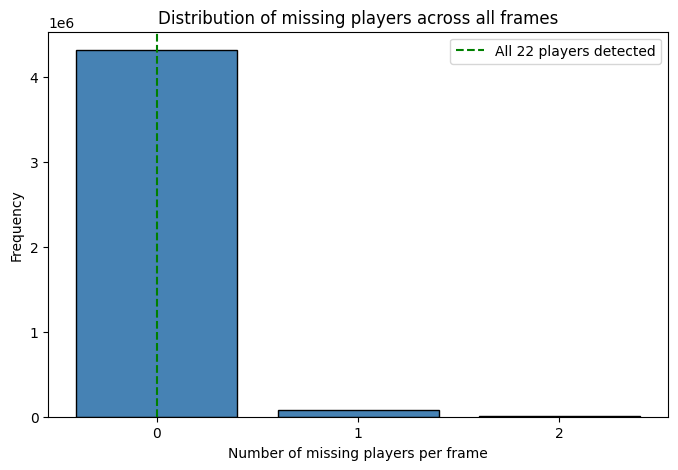

In [27]:
# Histogram of missing players across all frames
# frame_check is a dict: {missing_count: num_frames}

# Prepare data for histogram
missing_counts = sorted(frame_check.keys())
frequencies = [frame_check[count] for count in missing_counts]

plt.figure(figsize=(8,5))
plt.bar(missing_counts, frequencies, 
        width=0.8, 
        color="steelblue", 
        edgecolor="black",
        align='center')

plt.xlabel("Number of missing players per frame")
plt.ylabel("Frequency")
plt.title("Distribution of missing players across all frames")
plt.xticks(range(0, max(missing_counts) + 1))
plt.axvline(0, color="green", linestyle="--", label="All 22 players detected")
plt.legend()
plt.show()


# 5. Inspect Coordinate Range

in tracking data, figuring out the pitch coordinates and attack direction is crucial before doing anything like clustering, pitch control, or EPV. Let’s break it down into efficient checks you can run:

In [28]:
# Check coordinate ranges using a sample match
# X is from (-52,52), y is from (-34,34) with center being (0,0)
print("Coordinate ranges (from sample match):")
print("X range:", sample_tracking["x"].min(), "to", sample_tracking["x"].max())
print("Y range:", sample_tracking["y"].min(), "to", sample_tracking["y"].max())


Coordinate ranges (from sample match):
X range: -58.21 to 56.28
Y range: -37.91 to 37.29


## 6. Inferring Attack Direction

In football analysis, it is very common to normalize the **attack direction**:  
- Team A always attacks **left → right**  
- Team B always attacks **right → left**

Why normalize?  
- ⚖️ Ensures consistency across matches and halves  
- 📊 Makes aggregate statistics interpretable  
- 🎥 Helps coaches quickly understand visuals  

### Step 1: Identify kickoff frames
- At the start of **1st half** (`period=1`, `time=00:00:00.00`)  
- At the start of **2nd half** (`period=2`, `time=00:45:00.00`)  

### Step 2: Compute average X position of Team A
- If Team A’s avg X < midfield → Team A is on the left → attacking right  
- Otherwise → Team A is on the right → attacking left  

### Step 3: Store this as a new column
We’ll add a column `"attack_direction"` in the full dataset:  
- `"R"` = attacking right  
- `"L"` = attacking left


In [29]:
# Example for one match - load it fresh
example_match_id = df_matches.loc[1, 'id'] if len(df_matches) > 1 else df_matches.loc[0, 'id']
match_data = load_match_pandas(example_match_id)

# kickoff frame 1st half
kickoff1 = match_data[(match_data["period"] == 1) & 
                      (match_data["time"] == "00:00:00.00")]

# Step 1: freeze team rosters at kickoff1
players = kickoff1[~kickoff1["is_ball"]]
median_x = players["x"].median()
team_a_ids = players[players["x"] <= median_x]["player_id"].unique()
team_b_ids = players[players["x"] >  median_x]["player_id"].unique()

def assign_fixed_teams(df, team_a_ids, team_b_ids):
    df = df.copy()
    def label(pid, is_ball):
        if is_ball:
            return "Ball"
        elif pid in team_a_ids:
            return "Team A"
        elif pid in team_b_ids:
            return "Team B"
        else:
            return "Unknown"
    df["team"] = df.apply(lambda r: label(r["player_id"], r["is_ball"]), axis=1)
    return df

# Assign for kickoff frame
kickoff1 = assign_fixed_teams(kickoff1, team_a_ids, team_b_ids)

# Step 2: infer direction based on frozen team rosters
avg_x_team_a = kickoff1[kickoff1["team"]=="Team A"]["x"].mean()
attack_direction_team_a = "R" if avg_x_team_a < 0 else "L"  # <- use 0 as midpoint in raw coords (-52 to 52)
attack_direction_team_b = "L" if attack_direction_team_a == "R" else "R"

# Step 3: add to full match_data
match_data = assign_fixed_teams(match_data, team_a_ids, team_b_ids)
match_data["attack_dir_team_a"] = np.where(match_data["period"] == 1,
                                           attack_direction_team_a,
                                           "L" if attack_direction_team_a=="R" else "R")
match_data["attack_dir_team_b"] = np.where(match_data["period"] == 1,
                                           attack_direction_team_b,
                                           "L" if attack_direction_team_b=="R" else "R")

print("Team A attack direction in 1st half:", attack_direction_team_a)
print("Team B attack direction in 1st half:", attack_direction_team_b)


Team A attack direction in 1st half: R
Team B attack direction in 1st half: L


1st half means (Team A, Team B): 39.46, 62.03 -> Team A attacks R
2nd half means (Team A, Team B): 64.24, 42.52 -> Team A attacks L


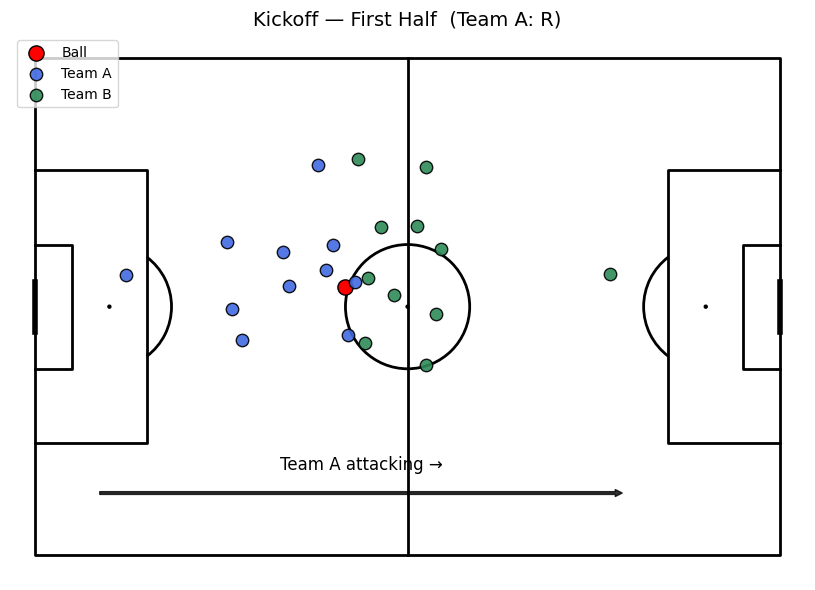

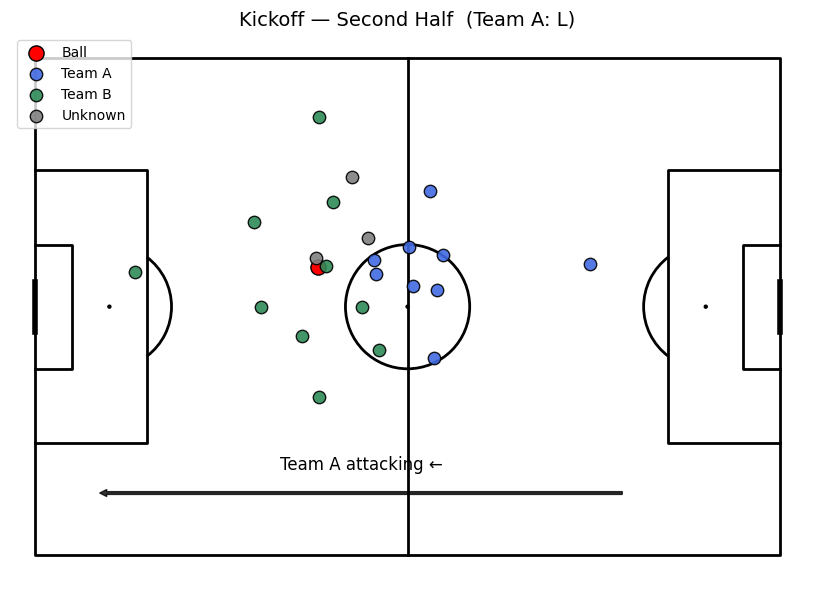

In [31]:
# ----------------------------
# Helpers
# ----------------------------

def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    """Scale & shift SkillCorner coords to FIFA 105x68 (origin at bottom-left)."""
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

def get_kickoff_frame(match_data: pd.DataFrame, period: int) -> pd.DataFrame:
    """Return kickoff frame for given half using match clock; fallback to first non-null time frame."""
    tstr = "00:00:00.00" if period == 1 else "00:45:00.00"
    kf = match_data[(match_data["period"] == period) & (match_data["time"] == tstr)]
    if kf.empty:
        period_df = match_data[(match_data["period"] == period) & match_data["time"].notna()]
        if period_df.empty:
            return pd.DataFrame(columns=match_data.columns)
        first_frame = period_df["frame"].min()
        kf = period_df[period_df["frame"] == first_frame]
    return kf.copy()

def derive_team_rosters_from_kickoff(kickoff_df: pd.DataFrame):
    """Define Team A/B ONCE from 1st-half kickoff by splitting on median x (native coords)."""
    players = kickoff_df[~kickoff_df["is_ball"]]
    medx = players["x"].median()
    team_a_ids = set(players.loc[players["x"] <= medx, "player_id"].unique())
    team_b_ids = set(players.loc[players["x"] >  medx, "player_id"].unique())
    return team_a_ids, team_b_ids

def assign_teams(df: pd.DataFrame, team_a_ids: set, team_b_ids: set) -> pd.DataFrame:
    """Tag each row with fixed 'team' based on rosters defined at 1st-half kickoff."""
    df = df.copy()
    def lab(pid, is_ball):
        if is_ball: return "Ball"
        if pid in team_a_ids: return "Team A"
        if pid in team_b_ids: return "Team B"
        return "Unknown"
    df["team"] = df.apply(lambda r: lab(r["player_id"], r["is_ball"]), axis=1)
    return df

def attack_dir_from_kickoff(kickoff_rescaled: pd.DataFrame, team_label="Team A"):
    """
    Infer attack direction for a team at kickoff (rescaled coords).
    If Team A's mean x < Team B's mean x -> Team A is on the left half -> attacks RIGHT ("R").
    Else -> attacks LEFT ("L").
    """
    mean_a = kickoff_rescaled.loc[kickoff_rescaled["team"] == team_label, "x_rescaled"].mean()
    mean_b = kickoff_rescaled.loc[kickoff_rescaled["team"] == ("Team B" if team_label=="Team A" else "Team A"), "x_rescaled"].mean()
    return "R" if mean_a < mean_b else "L", mean_a, mean_b

def plot_kickoff_with_attack(kickoff_df_rescaled, attack_dir, title):
    """Plot players at kickoff with an arrow showing Team A attack direction."""
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9, 6))
    colors = {"Team A": "royalblue", "Team B": "seagreen", "Ball": "red", "Unknown": "gray"}

    # scatter players/ball
    for team, grp in kickoff_df_rescaled.groupby("team"):
        if team == "Ball":
            ax.scatter(grp["x_rescaled"], grp["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")
        else:
            ax.scatter(grp["x_rescaled"], grp["y_rescaled"], c=colors.get(team, "gray"),
                       s=80, alpha=0.9, edgecolors="k", label=team)

    # arrow for Team A
    y_arrow = 70
    if attack_dir == "R":
        # arrow points from x=10 to x=95 (left -> right)
        ax.annotate("", xy=(95, y_arrow), xytext=(10, y_arrow),
                    arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
        ax.text(52.5, 67, "Team A attacking →", ha="center", va="bottom", fontsize=12)
    else:
        # arrow points from x=95 to x=10 (right -> left)
        ax.annotate("", xy=(10, y_arrow), xytext=(95, y_arrow),
                    arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
        ax.text(52.5, 67, "Team A attacking ←", ha="center", va="bottom", fontsize=12)

    ax.set_title(title + f"  (Team A: {attack_dir})", fontsize=14)
    ax.legend(loc="upper left")
    plt.show()

# ----------------------------
# Apply to one match
# ----------------------------

# Load a fresh match for this example
demo_match_id = df_matches.loc[0, 'id'] if len(df_matches) > 1 else df_matches.loc[0, 'id']
match_data = load_match_pandas(demo_match_id)

# get kickoff frames
kickoff1 = get_kickoff_frame(match_data, period=1)
kickoff2 = get_kickoff_frame(match_data, period=2)

# define Team A/B once from 1st-half kickoff (native coords)
team_a_ids, team_b_ids = derive_team_rosters_from_kickoff(kickoff1)

# tag teams in both kickoffs, then rescale
kickoff1 = assign_teams(kickoff1, team_a_ids, team_b_ids)
kickoff2 = assign_teams(kickoff2, team_a_ids, team_b_ids)
kickoff1_res = rescale_to_pitch(kickoff1)
kickoff2_res = rescale_to_pitch(kickoff2)

# infer Team A attack direction per half (robust: compare mean x of Team A vs Team B)
dir_p1, mA1, mB1 = attack_dir_from_kickoff(kickoff1_res, "Team A")
dir_p2, mA2, mB2 = attack_dir_from_kickoff(kickoff2_res, "Team A")
print(f"1st half means (Team A, Team B): {mA1:.2f}, {mB1:.2f} -> Team A attacks {dir_p1}")
print(f"2nd half means (Team A, Team B): {mA2:.2f}, {mB2:.2f} -> Team A attacks {dir_p2}")

# visualize
plot_kickoff_with_attack(kickoff1_res, dir_p1, "Kickoff — First Half")
plot_kickoff_with_attack(kickoff2_res, dir_p2, "Kickoff — Second Half")


## 7. Coordinate Transformation

Most providers have their own coordinate system.  
SkillCorner defines their coordinate system with the origin at the center of the pitch and then uses the actual dimentions of the pitch, which can be found in the meta data of each game. A pitch with pitch length 104 meters and witdh 68 meters would then have coordinates:  
- X ∈ [-52, 52]  
- Y ∈ [-34, 34]

In the st_dynamic.py file there is an example of how to use the actual coordinates when working with the SkillCorner data. In this lesson, the pitch is assumed to be 104*68 and it is transformed to FIFA coordinates as an example of how to make transformations.

We want to transform into **FIFA standard (105 × 68 meters)**:  
- X ∈ [0, 105]  
- Y ∈ [0, 68]  

Benefits:  
- 🧠 ML models trained on normalized input  
- 🏟️ Perfect match with `mplsoccer` pitch visuals  


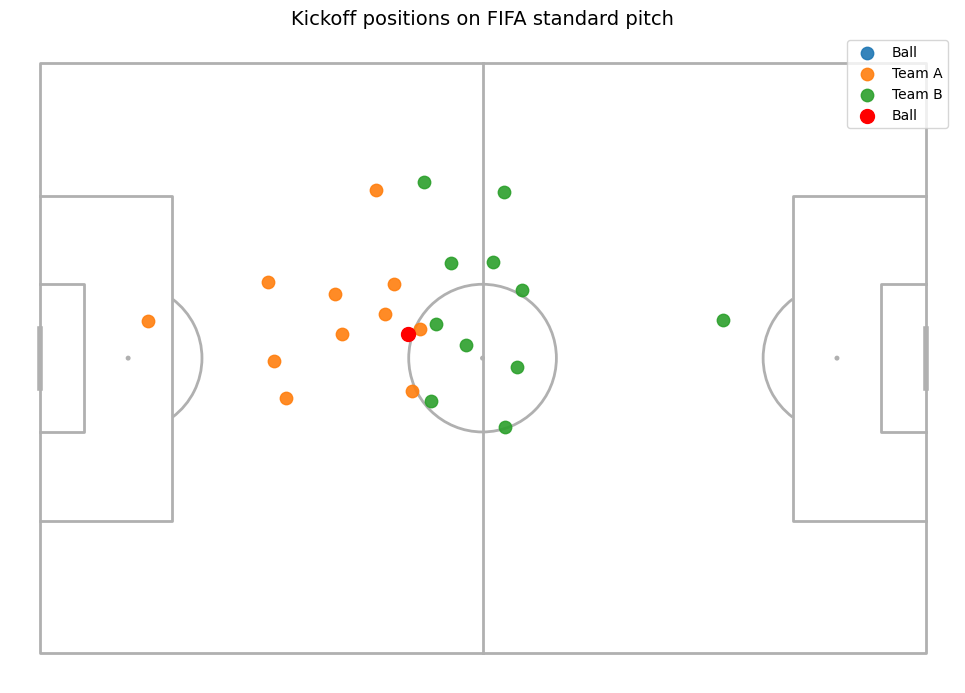

In [32]:
def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

# Apply to kickoff frame for visualization
kickoff1_scaled = rescale_to_pitch(kickoff1)

# Plot rescaled frame
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68)
fig, ax = pitch.draw(figsize=(10,7))

for team, group in kickoff1_scaled.groupby("team"):
    ax.scatter(group["x_rescaled"], group["y_rescaled"],
               label=team, s=80, alpha=0.9)

ax.scatter(kickoff1_scaled.loc[kickoff1_scaled["team"]=="Ball", "x_rescaled"],
           kickoff1_scaled.loc[kickoff1_scaled["team"]=="Ball", "y_rescaled"],
           c="red", s=100, label="Ball")

ax.set_title("Kickoff positions on FIFA standard pitch", fontsize=14)
ax.legend()
plt.show()


## 8) Normalize attack direction (one match)

Goal:
1) Identify **Team A** and **Team B** once at 1st-half kickoff (so colors don’t “follow the left side”).
2) Infer **Team A’s attack direction** at each half’s kickoff (R = right, L = left).
3) Add two new columns to `match_data`:
   - `team` ∈ {Team A, Team B, Ball}
   - `attack_dir` ∈ {R, L} (per row, based on the row’s half)
4) Create normalized coordinates `x_norm, y_norm` so **Team A always attacks →**.

Why do this?
- Aggregations (heatmaps, passing maps) become comparable across halves/matches.
- Coach/scout visuals are consistent and easier to interpret.


In [33]:
# --- 0) Small helpers (self-contained) ---

def rescale_to_pitch(df,
                     x_min=-52, x_max=52,  # SkillCorner native
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):  # FIFA
    """Scale & shift SkillCorner coords to FIFA 105x68 (origin bottom-left)."""
    df = df.copy()
    df["x_fifa"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_fifa"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

def get_kickoff_frame(match_df: pd.DataFrame, period: int) -> pd.DataFrame:
    """Return kickoff frame rows (all players+ball) for a period; fallback to first non-null time frame."""
    tstr = "00:00:00.00" if period == 1 else "00:45:00.00"
    kf = match_df[(match_df["period"] == period) & (match_df["time"] == tstr)]
    if kf.empty:
        cand = match_df[(match_df["period"] == period) & match_df["time"].notna()]
        if cand.empty:
            return pd.DataFrame(columns=match_df.columns)
        first_frame = cand["frame"].min()
        kf = cand[cand["frame"] == first_frame]
    return kf.copy()

def derive_team_rosters_from_kickoff(kickoff_df: pd.DataFrame):
    """
    Define Team A/B ONCE from 1st-half kickoff (native coords):
    Team A = players with x <= median_x; Team B = x > median_x. Ball excluded.
    """
    players = kickoff_df[~kickoff_df["is_ball"]]
    medx = players["x"].median()
    team_a_ids = set(players.loc[players["x"] <= medx, "player_id"].unique())
    team_b_ids = set(players.loc[players["x"] >  medx, "player_id"].unique())
    return team_a_ids, team_b_ids

def assign_teams(df: pd.DataFrame, team_a_ids: set, team_b_ids: set) -> pd.DataFrame:
    """Tag each row with fixed 'team' based on rosters from 1st-half kickoff."""
    df = df.copy()
    def lab(pid, is_ball):
        if is_ball: return "Ball"
        if pid in team_a_ids: return "Team A"
        if pid in team_b_ids: return "Team B"
        return "Unknown"
    df["team"] = df.apply(lambda r: lab(r["player_id"], r["is_ball"]), axis=1)
    return df

def infer_attack_dir_at_kickoff(kickoff_fifa: pd.DataFrame, team_label="Team A"):
    """
    Compare mean x_fifa of Team A vs Team B at kickoff:
    If Team A mean < Team B mean, Team A starts left → attacks RIGHT ("R"); else "L".
    """
    mean_a = kickoff_fifa.loc[kickoff_fifa["team"] == team_label, "x_fifa"].mean()
    mean_b = kickoff_fifa.loc[kickoff_fifa["team"] == ("Team B" if team_label=="Team A" else "Team A"), "x_fifa"].mean()
    return "R" if mean_a < mean_b else "L"


In [34]:
# --- 1) Select ONE match and prepare match_data ---

# Load a fresh match for normalization example
norm_match_id = df_matches.loc[0, 'id']
match_data = load_match_pandas(norm_match_id)

# Get kickoff frames
kickoff1 = get_kickoff_frame(match_data, period=1)          # 1st half
kickoff2 = get_kickoff_frame(match_data, period=2)          # 2nd half

# Derive fixed rosters ONCE (native coords)
team_a_ids, team_b_ids = derive_team_rosters_from_kickoff(kickoff1)

# Assign team labels across the whole match
match_data = assign_teams(match_data, team_a_ids, team_b_ids)

# Rescale entire match to FIFA coords (x_fifa, y_fifa)
match_data = rescale_to_pitch(match_data)

# Also rescale kickoff frames for direction inference
kickoff1 = rescale_to_pitch(assign_teams(kickoff1, team_a_ids, team_b_ids))
kickoff2 = rescale_to_pitch(assign_teams(kickoff2, team_a_ids, team_b_ids))

# Infer Team A attack direction per half
dir_p1 = infer_attack_dir_at_kickoff(kickoff1, "Team A")    # "R" or "L"
dir_p2 = infer_attack_dir_at_kickoff(kickoff2, "Team A")    # "R" or "L"

# Attach per-row attack_dir (by period)
match_data["attack_dir"] = np.where(match_data["period"] == 1, dir_p1,
                             np.where(match_data["period"] == 2, dir_p2, np.nan))

print(f"[{norm_match_id}] Team A attack direction — 1st half: {dir_p1}, 2nd half: {dir_p2}")
match_data[["period","frame","player_id","team","attack_dir","x_fifa","y_fifa"]].head()


[1021404] Team A attack direction — 1st half: R, 2nd half: L


,period,frame,player_id,team,attack_dir,x_fifa,y_fifa
0,1,10,13899,Team A,R,14.629327,34.97
1,1,10,13903,Team A,R,30.985096,29.63
2,1,10,32276,Team A,R,31.732212,40.35
3,1,10,8259,Team A,R,45.574038,17.22
4,1,10,4463,Team A,R,33.398077,45.42


**Normalize coordinates** so that Team A always attacks **left → right**.  
If `attack_dir == 'L'` in a half, flip *all* rows in that half (both teams + ball), so the orientation aligns.


In [35]:
# --- 2) Normalize coordinates to make Team A always attack right (→) ---

match_data["x_norm"] = match_data["x_fifa"]
match_data["y_norm"] = match_data["y_fifa"]

need_flip_p1 = (dir_p1 == "L")
need_flip_p2 = (dir_p2 == "L")

# flip half 1 if needed
mask_p1 = (match_data["period"] == 1) & need_flip_p1
match_data.loc[mask_p1, "x_norm"] = 105 - match_data.loc[mask_p1, "x_fifa"]
match_data.loc[mask_p1, "y_norm"] =  68 - match_data.loc[mask_p1, "y_fifa"]

# flip half 2 if needed
mask_p2 = (match_data["period"] == 2) & need_flip_p2
match_data.loc[mask_p2, "x_norm"] = 105 - match_data.loc[mask_p2, "x_fifa"]
match_data.loc[mask_p2, "y_norm"] =  68 - match_data.loc[mask_p2, "y_fifa"]

# quick sanity check at kickoffs: Team A should be left of Team B in BOTH halves now
k1_norm = match_data[(match_data["period"]==1) & (match_data["time"]=="00:00:00.00")]
k2_norm = match_data[(match_data["period"]==2) & (match_data["time"]=="00:45:00.00")]

mA1 = k1_norm.loc[k1_norm["team"]=="Team A","x_norm"].mean()
mB1 = k1_norm.loc[k1_norm["team"]=="Team B","x_norm"].mean()
mA2 = k2_norm.loc[k2_norm["team"]=="Team A","x_norm"].mean()
mB2 = k2_norm.loc[k2_norm["team"]=="Team B","x_norm"].mean()

print(f"Kickoff check (normalized):\n  1st half Team A vs B mean x: {mA1:.1f} vs {mB1:.1f}\n  2nd half Team A vs B mean x: {mA2:.1f} vs {mB2:.1f}")


Kickoff check (normalized):
  1st half Team A vs B mean x: 39.5 vs 62.0
  2nd half Team A vs B mean x: 40.8 vs 62.5


**What you should see in the check above:**
- After normalization, at both kickoffs **Team A mean x_norm < Team B mean x_norm** (Team A starts on the left in both halves).
- This guarantees that any aggregate visuals (e.g., heatmaps) are aligned left→right for Team A.


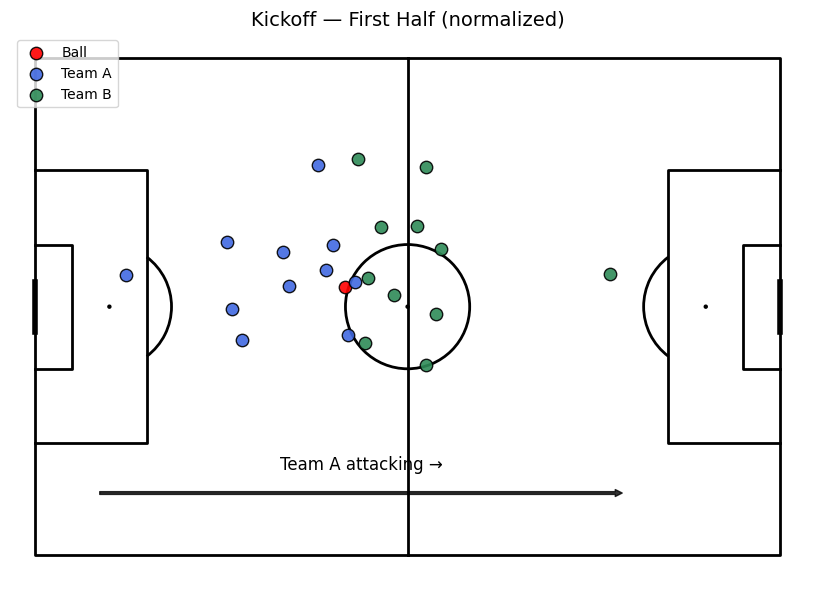

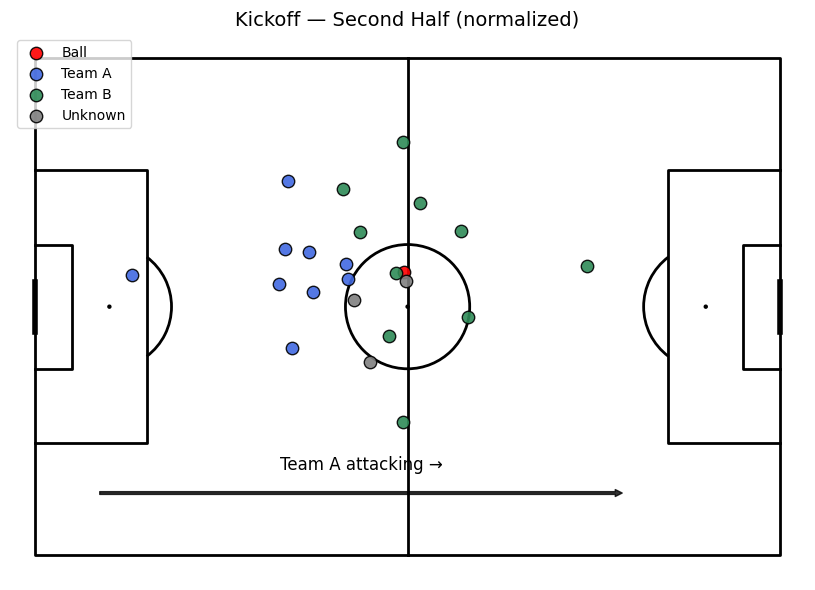

In [36]:

def plot_kickoff_with_attack_norm(df, period, title):
    """Plot kickoff positions (normalized) with arrow showing Team A attack →"""
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9, 6))
    colors = {"Team A": "royalblue", "Team B": "seagreen", "Ball": "red"}

    # filter kickoff frame of given half
    if period == 1:
        kickoff = df[(df["period"]==1) & (df["time"]=="00:00:00.00")]
    elif period == 2:
        kickoff = df[(df["period"]==2) & (df["time"]=="00:45:00.00")]
    else:
        raise ValueError("Only periods 1 or 2 supported")

    # plot dots
    for team, grp in kickoff.groupby("team"):
        ax.scatter(grp["x_norm"], grp["y_norm"],
                   c=colors.get(team, "gray"), s=80, alpha=0.9, edgecolors="k", label=team)

    # attack arrow (always right, because normalized)
    y_arrow = 70
    ax.annotate("", xy=(95, y_arrow), xytext=(10, y_arrow),
                arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
    ax.text(52.5, 67, "Team A attacking →", ha="center", va="bottom", fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper left")
    plt.show()

# --- Plot both halves ---
plot_kickoff_with_attack_norm(match_data, period=1, title="Kickoff — First Half (normalized)")
plot_kickoff_with_attack_norm(match_data, period=2, title="Kickoff — Second Half (normalized)")


## 9) Derive football-ready metrics: speed & acceleration

One of the first things to compute from tracking data is **player speed**:
- **Speed (m/s)** = how fast a player is moving at each frame.
- **Acceleration (m/s²)** = how quickly they change speed.

Why is this useful?
- Identifying sprints, presses, recovery runs.
- Linking physical output to tactical moments (pressing triggers, counter-attacks).
- Comparing players’ intensity across matches.

We will:
1. Use the **normalized coordinates** (`x_norm`, `y_norm`) so direction is consistent.  
2. Convert the `time` column into seconds.  
3. Compute **frame-to-frame displacement / time difference** for each player.  
4. Plot histograms of speed values to see typical distributions.


In [37]:
# --- Helper: convert time string to seconds ---
def parse_time_to_seconds(tstr):
    if pd.isna(tstr):
        return np.nan
    hh, mm, ss = tstr.split(":")
    return int(hh)*3600 + int(mm)*60 + float(ss)

# --- Add t_seconds column ---
match_data["t_seconds"] = match_data["time"].apply(parse_time_to_seconds)

# --- Compute speed & acceleration ---
match_data = match_data.sort_values(["player_id","period","frame"])

dx = match_data.groupby("player_id")["x_norm"].diff()
dy = match_data.groupby("player_id")["y_norm"].diff()
dt = match_data.groupby("player_id")["t_seconds"].diff()

# speed (m/s)
speed = np.sqrt(dx**2 + dy**2) / dt
match_data["speed_mps"] = speed.fillna(0)

# acceleration (m/s²)
accel = match_data.groupby("player_id")["speed_mps"].diff() / dt
match_data["accel_mps2"] = accel.fillna(0)

match_data[match_data.player_id > 0][["player_id","period","frame","x_norm","y_norm","speed_mps","accel_mps2"]].head()


,player_id,period,frame,x_norm,y_norm,speed_mps,accel_mps2
714282,688,2,40980,88.048558,45.52,0.000000,0.000000
714305,688,2,40981,88.058654,45.44,0.806346,8.063456
714328,688,2,40982,88.078846,45.36,0.825090,0.187440
714351,688,2,40983,88.088942,45.28,0.806346,-0.187440
714374,688,2,40984,88.109135,45.19,0.922374,1.160279


### Speed distributions

Let’s check how speeds are distributed across the match.  
We expect:
- Most values around **2–5 m/s** (jogging, light movement).  
- Fewer values above **7 m/s** (sprints).  
- Outliers can be ball coordinates or tracking errors.


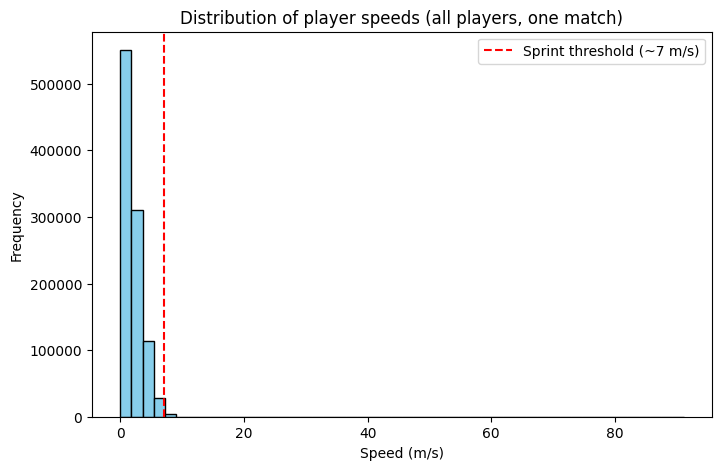

In [38]:
plt.figure(figsize=(8,5))
plt.hist(match_data.loc[~match_data["is_ball"], "speed_mps"], bins=50,
         color="skyblue", edgecolor="k")
plt.axvline(7, color="red", linestyle="--", label="Sprint threshold (~7 m/s)")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.title("Distribution of player speeds (all players, one match)")
plt.legend()
plt.show()


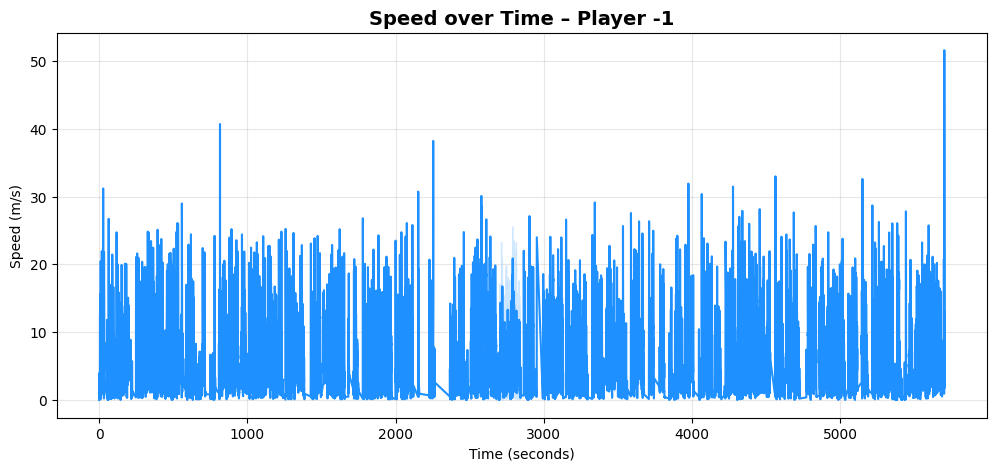

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick one player (change the ID to any player_id)
player_id = match_data["player_id"].unique()[0]
player_df = match_data[match_data["player_id"] == player_id].copy()

plt.figure(figsize=(12, 5))
sns.lineplot(data=player_df, x="t_seconds", y="speed_mps", color="dodgerblue")
plt.title(f"Speed over Time – Player {player_id}", fontsize=14, weight="bold")
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.grid(alpha=0.3)
plt.show()


## ⚙️ Interpolation and Smoothing of Ball Speed

When working with **football tracking data**, raw positional signals (x, y coordinates) often contain **noise and missing frames** — due to occlusion, tracking errors, or players moving too fast across the camera view.  
If we directly compute speed as `Δdistance / Δtime`, this noise leads to **erratic speed spikes** (e.g., unrealistic 50 m/s bursts).

To obtain physically meaningful, smooth speed curves, we apply two key preprocessing steps:

### 🔹 1. Interpolation of Missing Positions
Tracking systems sometimes lose the ball or a player for a few frames.  
We linearly **interpolate small gaps** (e.g., up to 0.4 seconds, ~10 frames) to fill in missing positions smoothly:

\[
x_{interp}(t) = x_{prev} + \frac{(x_{next} - x_{prev})}{(t_{next} - t_{prev})} \cdot (t - t_{prev})
\]

This ensures short gaps do not break continuity in motion.

---

### 🔹 2. Rolling Median Smoothing
Even after interpolation, subtle jitter remains.  
We apply a **centered rolling median filter** (e.g., 0.7 seconds window) over positions:

\[
x_{smooth}(t) = \text{median}\big(x_{interp}(t - w/2), \ldots, x_{interp}(t + w/2)\big)
\]

This smooths out sudden, noisy fluctuations while keeping true direction changes intact.

---

### 🔹 3. Velocity and Speed Calculation
Once smoothed positions are obtained, we estimate velocities via **central differences**:

\[
v_x(t) = \frac{x_{smooth}(t+1) - x_{smooth}(t-1)}{2 \, \Delta t}
\]
\[
v_y(t) = \frac{y_{smooth}(t+1) - y_{smooth}(t-1)}{2 \, \Delta t}
\]
\[
\text{Speed}(t) = \sqrt{v_x(t)^2 + v_y(t)^2}
\]

Finally, we **clip extreme values** (e.g., > 40 m/s) to remove outliers caused by residual tracking errors.

---

### 🧠 Why This Matters
- Produces **realistic, continuous** motion profiles  
- Prevents **artificial spikes** in velocity and acceleration  
- Essential for accurate downstream analyses (e.g., sprints, ball flight, fatigue modeling)

---

✅ In summary:
> **Interpolation** fixes missing data,  
> **Smoothing** removes noise,  
> and the result is a **clean, physically valid speed signal** ready for analysis and visualization.


In [40]:
## helper fucntions

import pandas as pd
import numpy as np

def to_seconds(series: pd.Series) -> pd.Series:
    """
    Convert time to seconds.
    Handles strings like 'HH:MM:SS.ff' (e.g., '00:00:00.10'),
    numeric seconds, and large integers/floats in ms.
    Returns a float Series.
    """
    # if already numeric-ish, start there
    s_num = pd.to_numeric(series, errors="coerce")

    # try timedelta parsing for strings like HH:MM:SS.ff
    s_td = pd.to_timedelta(series.astype(str).str.strip().str.replace(",", ".", regex=False),
                           errors="coerce")
    s_sec_td = s_td.dt.total_seconds()

    # prefer timedelta parse when available, else numeric
    s = s_sec_td.fillna(s_num)

    # if values look like milliseconds (very large), convert to seconds
    if s.notna().any():
        median_val = s.dropna().median()
        # heuristic: median > 1e6 suggests ms ticks (e.g., 1,650,000,000)
        if median_val is not None and median_val > 1e6:
            s = s / 1000.0

    return s.astype(float)


def estimate_fps_from_time_df(df: pd.DataFrame, group_cols=("match_id",)) -> float:
    """
    Estimate frames-per-second from median time delta.
    Works even if you pass only ball rows or all rows.
    """
    t = to_seconds(df["time"])
    # compute dt within each group (match)
    if not isinstance(group_cols, (list, tuple)):
        group_cols = (group_cols,)
    dt = t.groupby([df[c] for c in group_cols]).diff().astype(float)
    dt = dt[(dt > 0) & dt.notna()]
    if dt.empty:
        return 25.0
    fps = 1.0 / float(dt.median())
    return float(np.clip(fps, 5, 120))


In [41]:
def compute_ball_kinematics(tr_df: pd.DataFrame,
                            interp_gap_s: float = 0.40,
                            smooth_window_s: float = 0.70,
                            clip_speed_mps: float = 40.0) -> pd.DataFrame:
    """
    Returns one row per ball frame with columns:
      match_id, frame, time_s, x_s, y_s, vx_mps, vy_mps, speed_mps, fps_used
    """
    ball = tr_df[tr_df["is_ball"]].copy()
    # parse time
    ball["time_s"] = to_seconds(ball["time"])
    # numeric positions
    ball["x_norm"] = pd.to_numeric(ball["x_norm"], errors="coerce")
    ball["y_norm"] = pd.to_numeric(ball["y_norm"], errors="coerce")
    ball["frame"] = pd.to_numeric(ball["frame"], errors="coerce")

    # sort per match/frame
    ball = ball.sort_values(["match_id", "frame"]).reset_index(drop=True)

    # fps & dt
    fps = estimate_fps_from_time_df(ball, group_cols=("match_id",))
    dt = 1.0 / fps

    # convert seconds -> frames for parameters
    max_gap_frames = max(1, int(round(interp_gap_s * fps)))
    window_frames  = max(3, int(round(smooth_window_s * fps)))
    if window_frames % 2 == 0:  # make odd for centered window
        window_frames += 1

    # interpolate short gaps only
    x = ball["x_norm"]
    y = ball["y_norm"]
    x_i = x.interpolate(limit=max_gap_frames, limit_direction="both")
    y_i = y.interpolate(limit=max_gap_frames, limit_direction="both")

    # smooth with centered rolling median
    x_s = x_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()
    y_s = y_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()


    #x_s, y_s are the smoothed/interpolated positions used to compute speed.

    # central differences for velocity
    vx = (x_s.shift(-1) - x_s.shift(1)) / (2*dt)
    vy = (y_s.shift(-1) - y_s.shift(1)) / (2*dt)

    speed = np.sqrt(vx**2 + vy**2).clip(lower=0, upper=clip_speed_mps)

    kin = pd.DataFrame({
        "match_id": ball["match_id"].values,
        "frame":    ball["frame"].astype("Int64").values,
        "time_s":   ball["time_s"].values,
        "x_s":      x_s.values,
        "y_s":      y_s.values,
        "vx_mps":   vx.values,
        "vy_mps":   vy.values,
        "speed_mps_smooth": speed.values,
        "fps_used": fps
    })
    return kin


In [42]:
ball_data= match_data[match_data['player_id']== -1]

In [43]:
kin = compute_ball_kinematics(ball_data, interp_gap_s=0.40, smooth_window_s=0.70)
kin.head(12)


,match_id,frame,time_s,x_s,y_s,vx_mps,vy_mps,speed_mps_smooth,fps_used
0,1021404,10,0.0,50.081971,37.065,NaN,NaN,NaN,10.0
1,1021404,11,0.1,50.238462,37.130,1.665865,0.475,1.732262,10.0
2,1021404,12,0.2,50.415144,37.160,1.766827,0.300,1.792115,10.0
3,1021404,13,0.3,50.591827,37.190,2.094952,0.600,2.179180,10.0
4,1021404,14,0.4,50.834135,37.280,2.019231,0.900,2.210722,10.0
5,1021404,15,0.5,50.995673,37.370,1.262019,0.900,1.550062,10.0
6,1021404,16,0.6,51.086538,37.460,0.807692,0.900,1.209284,10.0
7,1021404,17,0.7,51.157212,37.550,0.555288,0.800,0.973830,10.0
8,1021404,18,0.8,51.197596,37.620,0.353365,0.650,0.739843,10.0
9,1021404,19,0.9,51.227885,37.680,0.353365,0.550,0.653733,10.0


In [44]:
print("Speed stats (m/s):")
print(kin["speed_mps_smooth"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

Speed stats (m/s):
count    45703.00
mean         5.97
std          5.37
min          0.00
50%          4.41
90%         13.63
99%         22.35
max         40.00
Name: speed_mps_smooth, dtype: float64


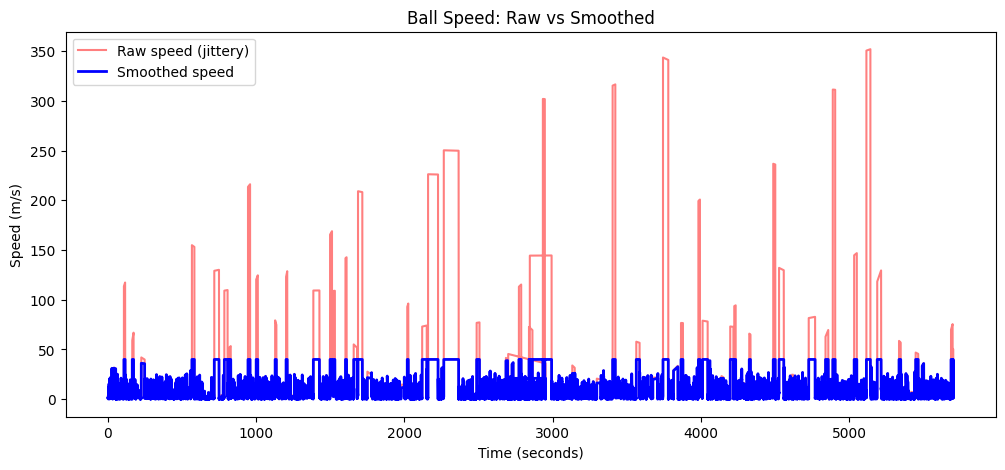

In [45]:
import matplotlib.pyplot as plt

# Take a slice of ball data
ball = match_data[match_data["is_ball"]].copy()
ball["time_s"] = to_seconds(ball["time"])

# Raw speed (no interp, no smoothing)
fps = estimate_fps_from_time_df(ball)
dt = 1.0 / fps
x_raw = ball["x_norm"].astype(float)
y_raw = ball["y_norm"].astype(float)
vx_raw = (x_raw.shift(-1) - x_raw.shift(1)) / (2*dt)
vy_raw = (y_raw.shift(-1) - y_raw.shift(1)) / (2*dt)
speed_raw = np.sqrt(vx_raw**2 + vy_raw**2)

# Cleaned speed
kin = compute_ball_kinematics(match_data, interp_gap_s=0.4, smooth_window_s=0.7)
speed_clean = kin.set_index("frame")["speed_mps_smooth"]

# Align by frame
df_plot = pd.DataFrame({
    "time_s": ball["time_s"].values,
    "speed_raw": speed_raw.values,
    "speed_clean": speed_clean.reindex(ball["frame"].values).values
})

# Plot
plt.figure(figsize=(12,5))
plt.plot(df_plot["time_s"], df_plot["speed_raw"], alpha=0.5, label="Raw speed (jittery)", color="red")
plt.plot(df_plot["time_s"], df_plot["speed_clean"], label="Smoothed speed", color="blue", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Ball Speed: Raw vs Smoothed")
plt.legend()
plt.show()


## 10) Team Structure & Shape Basics

A key advantage of tracking data is that we can measure **team structure**:
- **Convex hull** = the smallest polygon that contains all players (like stretching a rubber band around them).
- **Voronoi diagram** = partitions the pitch into regions where each region belongs to the closest player.

These concepts help us understand:
- **Team compactness** (convex hull area).
- **Pitch control** and **spatial dominance** (Voronoi).
- How attacking/defending teams shape up at a given frame.

We’ll demonstrate both for one random frame.


## 1. Convex Hull

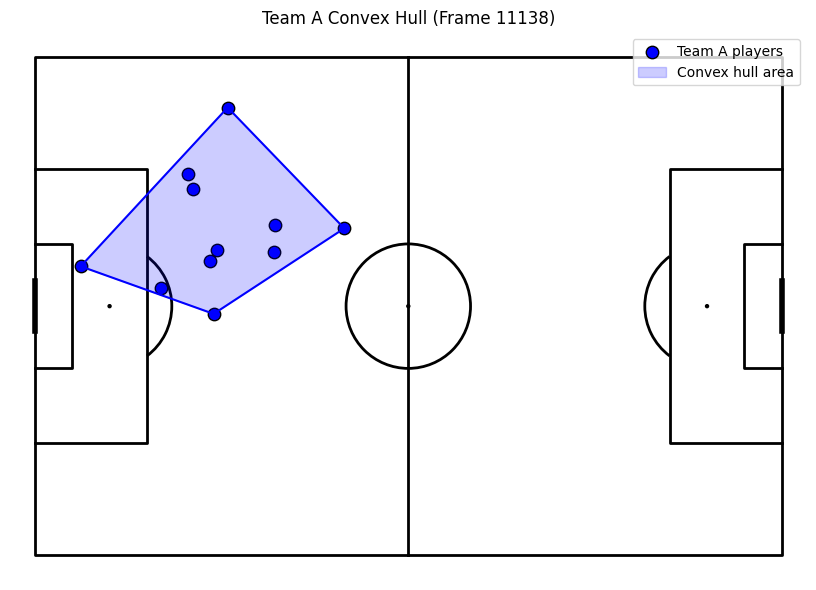

In [46]:
# pick one random frame from normalized data
frame_id = match_data["frame"].sample(1, random_state=1).iloc[0]
frame_df = match_data[(match_data["frame"] == frame_id) & (~match_data["is_ball"])]

# select Team A only
teamA = frame_df[frame_df["team"]=="Team A"]

# convex hull
points = teamA[["x_norm","y_norm"]].to_numpy()
hull = ConvexHull(points)

# plot
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9,6))

# scatter players
ax.scatter(teamA["x_norm"], teamA["y_norm"], c="blue", s=80, edgecolors="k", label="Team A players")

# draw hull polygon
for simplex in hull.simplices:
    ax.plot(points[simplex, 0], points[simplex, 1], "b-")

ax.fill(points[hull.vertices,0], points[hull.vertices,1], color="blue", alpha=0.2, label="Convex hull area")
ax.set_title(f"Team A Convex Hull (Frame {frame_id})")
ax.legend()
plt.show()


In [47]:
print(frame_df["team"].value_counts(dropna=False))


team
Team B    11
Team A    11
Name: count, dtype: int64


In [48]:
from scipy.spatial import ConvexHull
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def get_clean_frame_teams(df, frame_id):
    """
    Returns two cleaned team DataFrames for a given frame,
    excluding unknown or invalid entities.
    """
    frame_df = df[(df["frame"] == frame_id) & (~df["is_ball"])].copy()

    # Drop missing or unknown teams
    frame_df = frame_df[frame_df["team"].notna() & (frame_df["team"] != "Unknown")]

    # Check how many unique teams exist
    teams = frame_df["team"].unique()
    if len(teams) < 2:
        raise ValueError(f"⚠️ Only one team detected in frame {frame_id}: {teams}")

    teamA_df = frame_df[frame_df["team"] == teams[0]]
    teamB_df = frame_df[frame_df["team"] == teams[1]]

    return teamA_df, teamB_df


def plot_team_hulls(df, frame_id):
    """Plots convex hulls for both teams in a given frame."""
    teamA_df, teamB_df = get_clean_frame_teams(df, frame_id)

    def compute_hull(team_df):
        pts = team_df[["x_norm", "y_norm"]].to_numpy()
        if len(pts) >= 3:
            return ConvexHull(pts)
        return None

    hullA = compute_hull(teamA_df)
    hullB = compute_hull(teamB_df)

    # Draw pitch
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(10, 7))

    # Plot teams
    for team_df, color, label, hull in [
        (teamA_df, "#0077B6", "Team A", hullA),
        (teamB_df, "#D62828", "Team B", hullB),
    ]:
        ax.scatter(team_df["x_norm"], team_df["y_norm"], c=color, s=90, edgecolors="k", label=f"{label} players")
        if hull is not None:
            pts = team_df[["x_norm", "y_norm"]].to_numpy()
            ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1], color=color, alpha=0.2, label=f"{label} hull")
            for s in hull.simplices:
                ax.plot(pts[s, 0], pts[s, 1], color=color, lw=1.5)

    ax.set_title(f"Convex Hulls — Frame {frame_id}", fontsize=14, weight="bold")
    ax.legend(loc="upper right")
    plt.show()


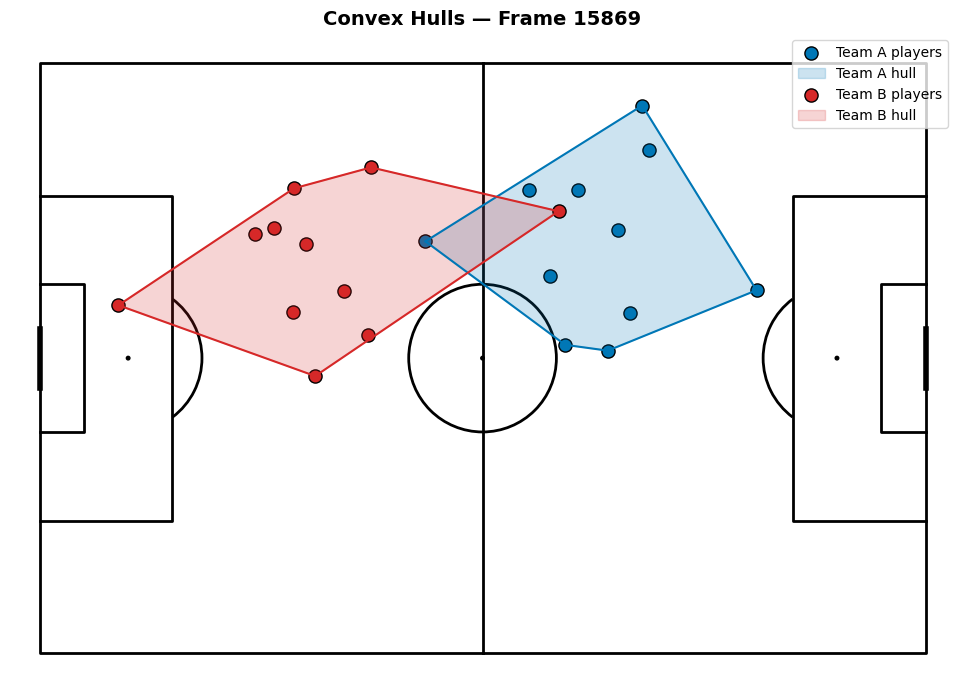

In [50]:
valid_frames = (
    match_data[~match_data["is_ball"] & (match_data["team"] != "Unknown")]
    .groupby("frame")["player_id"]
    .nunique()
)
valid_frames = valid_frames[valid_frames == 22].index

frame_id = np.random.choice(valid_frames)
plot_team_hulls(match_data, frame_id)


## 2. Voronoi

✅ Found 22986 valid 11v11 frames.


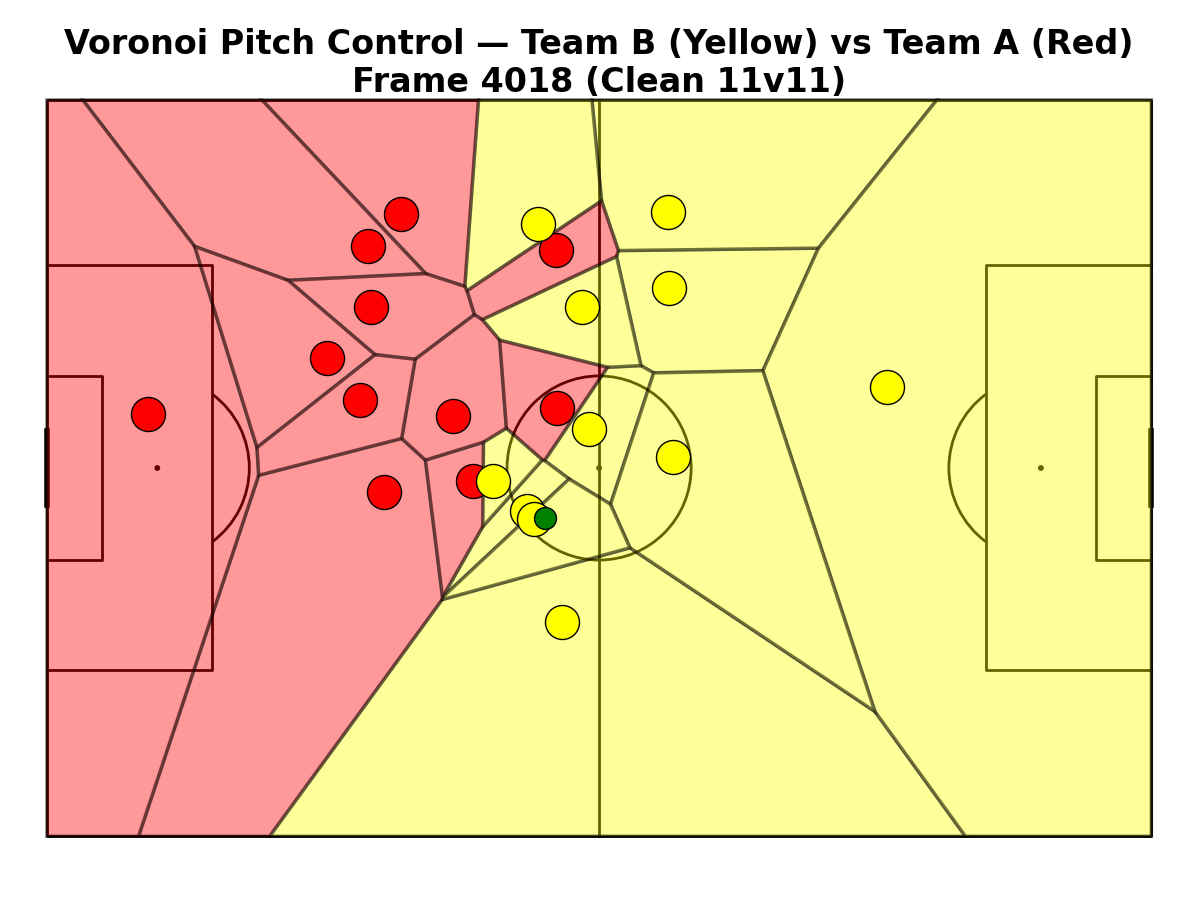

In [51]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd

# --- 1️⃣ Find only frames with 22 valid players (no 'Unknown') ---
valid_frames = (
    match_data[~match_data["is_ball"] & match_data["team"].notna() & (match_data["team"] != "Unknown")]
    .groupby("frame")["player_id"]
    .nunique()
)
valid_frames = valid_frames[valid_frames == 22].index

if len(valid_frames) == 0:
    raise ValueError("❌ No clean 11v11 frames available. Check your dataset or team labeling.")
else:
    print(f"✅ Found {len(valid_frames)} valid 11v11 frames.")

# --- 2️⃣ Randomly select one valid frame ---
frame_id = np.random.choice(valid_frames)
frame_df = match_data[(match_data["frame"] == frame_id) & (~match_data["is_ball"])].copy()

teams = frame_df["team"].unique()
teamA, teamB = teams[:2]  # pick the two real teams

# --- 3️⃣ Separate teams ---
teamA_df = frame_df[frame_df["team"] == teamA]
teamB_df = frame_df[frame_df["team"] == teamB]

# --- 4️⃣ Prepare pitch ---
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)

# --- 5️⃣ Compute Voronoi for both teams ---
teammates = np.concatenate([np.ones(len(teamA_df)), np.zeros(len(teamB_df))])
x_all = np.concatenate([teamA_df["x_norm"], teamB_df["x_norm"]])
y_all = np.concatenate([teamA_df["y_norm"], teamB_df["y_norm"]])

team_voronoiA, team_voronoiB = pitch.voronoi(x_all, y_all, teammates)

# --- 6️⃣ Plot Voronoi polygons ---
pitch.polygon(team_voronoiA, ax=ax["pitch"], color="yellow", ec="black", lw=2.5, alpha=0.4, zorder=2)
pitch.polygon(team_voronoiB, ax=ax["pitch"], color="red", ec="black", lw=2.5, alpha=0.4, zorder=2)

# --- 7️⃣ Plot players ---
pitch.scatter(teamA_df["x_norm"], teamA_df["y_norm"], color="yellow", edgecolors="black", s=600, ax=ax["pitch"], zorder=4)
pitch.scatter(teamB_df["x_norm"], teamB_df["y_norm"], color="red", edgecolors="black", s=600, ax=ax["pitch"], zorder=3)

# --- 8️⃣ Plot ball if available ---
ball = match_data[(match_data["frame"] == frame_id) & (match_data["is_ball"])]
if not ball.empty:
    pitch.scatter(ball["x_norm"], ball["y_norm"], color="green", s=250, edgecolors="black", ax=ax["pitch"], zorder=5)

# --- 9️⃣ Final touches ---
fig.suptitle(
    f"Voronoi Pitch Control — {teamA} (Yellow) vs {teamB} (Red)\nFrame {frame_id} (Clean 11v11)",
    fontsize=24, weight="bold"
)
plt.show()


## 3. Combined Spatial Analysis


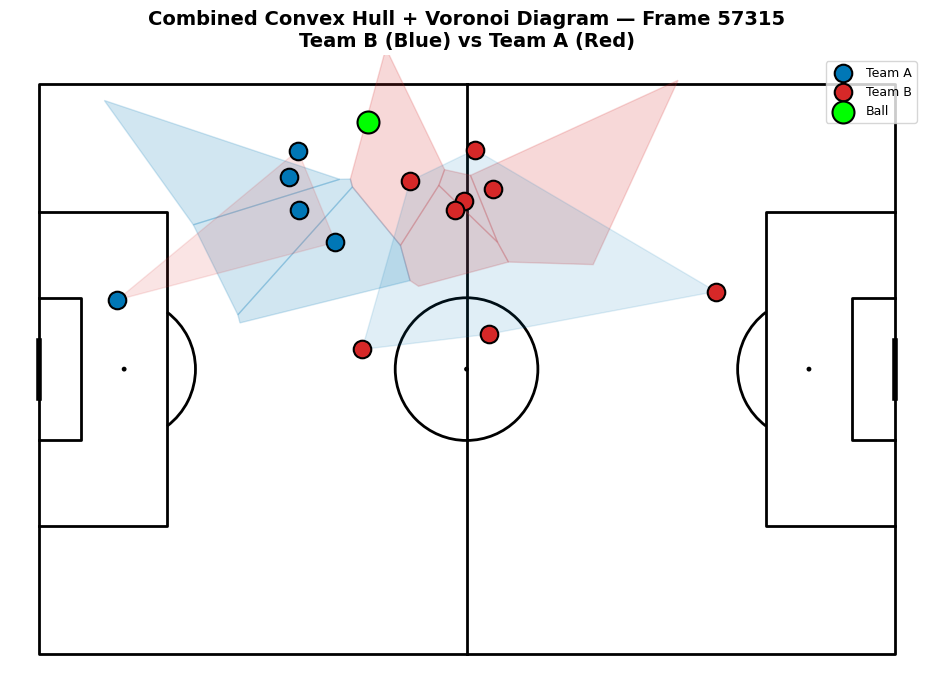

In [52]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.spatial import Voronoi, ConvexHull
import numpy as np

# --- 1️⃣ Select a single random frame ---
frame_id = match_data["frame"].sample(1, random_state=7).iloc[0]
frame_df = match_data[(match_data["frame"] == frame_id) & (~match_data["is_ball"])].copy()

# --- 2️⃣ Filter only valid teams ---
frame_df_valid = frame_df[frame_df["team"].isin(["Team A", "Team B"])]

teams = frame_df_valid["team"].unique()
teamA, teamB = teams[:2]

# --- 3️⃣ Compute Convex Hulls ---
def get_hull(df):
    pts = df[["x_norm", "y_norm"]].to_numpy()
    return ConvexHull(pts) if len(pts) >= 3 else None

teamA_df = frame_df_valid[frame_df_valid["team"] == teamA]
teamB_df = frame_df_valid[frame_df_valid["team"] == teamB]
hullA = get_hull(teamA_df)
hullB = get_hull(teamB_df)

# --- 4️⃣ Build Voronoi diagram ---
points_all = frame_df_valid[["x_norm", "y_norm"]].to_numpy()
teams_all = frame_df_valid["team"].to_numpy()
vor = Voronoi(points_all)

# --- 5️⃣ Draw pitch ---
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(10, 7))

colors = {"Team A": "#0077B6", "Team B": "#D62828"}

# --- 6️⃣ Plot Voronoi regions ---
for region_index, player_team in zip(vor.point_region, teams_all):
    region = vor.regions[region_index]
    if not -1 in region and len(region) > 0:
        polygon = [vor.vertices[i] for i in region]
        ax.fill(*zip(*polygon), color=colors[player_team], alpha=0.18, zorder=1)

# --- 7️⃣ Plot Convex Hulls (team shape) ---
if hullA:
    ptsA = teamA_df[["x_norm", "y_norm"]].to_numpy()
    ax.fill(ptsA[hullA.vertices, 0], ptsA[hullA.vertices, 1], color="#0077B6", alpha=0.12, zorder=2)
if hullB:
    ptsB = teamB_df[["x_norm", "y_norm"]].to_numpy()
    ax.fill(ptsB[hullB.vertices, 0], ptsB[hullB.vertices, 1], color="#D62828", alpha=0.12, zorder=2)

# --- 8️⃣ Plot players ---
for team in ["Team A", "Team B"]:
    df_team = frame_df_valid[frame_df_valid["team"] == team]
    ax.scatter(df_team["x_norm"], df_team["y_norm"], c=colors[team], s=160, edgecolors="black", lw=1.5, label=team, zorder=3)

# --- 9️⃣ Ball position (if available) ---
ball = match_data[(match_data["frame"] == frame_id) & (match_data["is_ball"])]
if not ball.empty:
    ax.scatter(ball["x_norm"], ball["y_norm"], color="lime", s=250, edgecolors="black", lw=1.5, zorder=4, label="Ball")

# --- 🔟 Final touch ---
ax.set_title(
    f"Combined Convex Hull + Voronoi Diagram — Frame {frame_id}\n"
    f"{teamA} (Blue) vs {teamB} (Red)",
    fontsize=14, weight="bold"
)
ax.legend(loc="upper right", fontsize=9)
plt.show()


### What do we learn?
- **Convex hull**: tells us how spread or compact a team is (defensive block vs wide attacking shape).  
- **Voronoi**: shows which areas of the pitch each player is “closest” to — a first step towards **pitch control models**.  

👉 These shapes form the building blocks for **defensive line detection, compactness measures, and pitch control analysis**.


# 📚 Section 11: Synchronizing Events with Tracking

## 11.1 Why Synchronization Matters

We now have two worlds of data:

Tracking data (continuous): every player + ball position at every frame.

Dynamic events (discrete): football actions (passes, carries, shots, duels, etc.), each referencing specific frame_start and frame_end.

To analyze tactics properly, we need to merge these two so that:

Each event has the freeze frame of all players at its start (and optionally at its end).

We know exactly where the teammates and opponents were positioned.

We can compute features such as defensive line, distance to defenders, or passing options.

## 11.2 Best Practice: Use Frame IDs

⚠️ Never merge purely based on time (timestamps), because:

- They may have rounding/encoding errors.

- Different data sources may have slight clock drifts.

✅ Skillcorner already sync the data and provides a frame mapping in the dynamic events. Therefore we merge on frame, since this is the synchronization key between events and tracking.

- Each event has frame_start and frame_end.

- Each row in tracking has a frame.

## 11.3 Implementation

We’ll create a freeze-frame DataFrame that enriches each event with the positions of all players + ball at the relevant frame.

In [6]:
# Build events and tracking dictionaries (lazy - no full loading)
# We'll load matches on demand when needed

all_events = {}
available_tracking_ids = {int(f.stem) for f in parquet_files}

print(f"Loading event data for {len(df_matches)} matches...")
for match_id in df_matches["id"].values:
    # Load events
    try:
        df_events = pd.read_parquet(BASE_DIR / 'dynamic' / f"{match_id}.parquet")
        all_events[match_id] = df_events
        
        # Check if tracking is available
        has_tracking = match_id in available_tracking_ids
        print(f"Match {match_id}: Events {df_events.shape}, Tracking: {'✓' if has_tracking else '✗'}")
    except Exception as e:
        print(f"⚠️ No dynamic events for match {match_id}: {e}")
        continue

print(f"\n✅ Loaded {len(all_events)} event files")


Loading event data for 99 matches...
Match 1021404: Events (5926, 294), Tracking: ✓
Match 1036527: Events (5369, 294), Tracking: ✓
Match 1048195: Events (5298, 294), Tracking: ✓
Match 1064327: Events (4987, 294), Tracking: ✓
Match 1096879: Events (5286, 294), Tracking: ✓
Match 1103734: Events (5760, 294), Tracking: ✓
Match 1114154: Events (5216, 294), Tracking: ✓
Match 1121546: Events (6623, 294), Tracking: ✓
Match 1129394: Events (5769, 294), Tracking: ✓
Match 1137151: Events (5359, 294), Tracking: ✓
Match 1146865: Events (5268, 294), Tracking: ✓
Match 1184210: Events (5224, 294), Tracking: ✓
Match 1193411: Events (5300, 294), Tracking: ✓
Match 1204769: Events (5514, 294), Tracking: ✓
Match 1227667: Events (4808, 294), Tracking: ✓
Match 1234494: Events (6035, 294), Tracking: ✓
Match 1242274: Events (5332, 294), Tracking: ✓
⚠️ No dynamic events for match 1274919: [Errno 2] No such file or directory: '/home/macaco3001/Projectos/Twelve/twelve-deep-learning/RealMadrid/dynamic/1274919.parq

In [ ]:
# Clean up any existing freeze frames
if 'df_freeze_start' in globals():
    del df_freeze_start
if 'all_freezes' in globals():
    del all_freezes
import gc
gc.collect()
print("✓ Cleaned up existing variables")

✓ Cleaned up existing variables


: 

In [8]:
# Test with one match first
test_match_id = list(all_events.keys())[0]
print(f"Testing with match {test_match_id}")

df_events_test = all_events[test_match_id]
print(f"Events shape: {df_events_test.shape}")
print(f"Event types: {df_events_test['event_type'].unique()}")

# Check for player_possession events
poss_events = df_events_test[df_events_test["event_type"] == "player_possession"]
print(f"Player possession events: {len(poss_events)}")

if len(poss_events) > 0:
    print(f"Sample event columns: {poss_events.columns.tolist()[:10]}")

Testing with match 1021404
Events shape: (5926, 294)
Event types: ['player_possession' 'passing_option' 'on_ball_engagement' 'off_ball_run']
Player possession events: 1198
Sample event columns: ['event_id', 'index', 'match_id', 'frame_start', 'frame_end', 'frame_physical_start', 'time_start', 'time_end', 'minute_start', 'second_start']


In [11]:
# Test loading tracking and merging for one match
print(f"\n📍 Loading tracking for match {test_match_id}...")
df_tracking_test = load_match_pandas(test_match_id)
print(f"Tracking shape: {df_tracking_test.shape}")
print(f"Tracking columns: {df_tracking_test.columns.tolist()[:10]}")

# Prepare events
df_events_pos = df_events_test[df_events_test["event_type"] == "player_possession"]

# Check required columns
required_cols = ["event_id", "match_id", "frame_start", "frame_end"]
print(f"\n✓ Has required columns: {all(c in df_events_pos.columns for c in required_cols)}")

# Try merge
print(f"\n🔗 Attempting merge...")
df_freeze_test = df_tracking_test.merge(
    df_events_pos,
    left_on=["match_id", "frame"],
    right_on=["match_id", "frame_end"],
    how="inner"
)
print(f"Result shape: {df_freeze_test.shape}")

if len(df_freeze_test) > 0:
    print(f"✅ Successfully created {len(df_freeze_test):,} freeze-frame rows for match {test_match_id}")
else:
    print(f"⚠️ No freeze frames created - checking data compatibility...")


📍 Loading tracking for match 1021404...
Tracking shape: (1051215, 9)
Tracking columns: ['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected', 'is_ball', 'x', 'y']

✓ Has required columns: True

🔗 Attempting merge...
Result shape: (27554, 302)
✅ Successfully created 27,554 freeze-frame rows for match 1021404


## 11.4 Freeze-Frame Construction

We now join tracking onto events.

For each event_id, get the frame_start (or frame_end).

Attach all tracking rows where frame == frame_end.

In [7]:
# --- Build freeze frames for all matches (batch processing) ---
print("Building freeze frames by processing matches one at a time...")

all_freezes = []
processed_count = 0

for match_id in df_matches["id"].values:
    if match_id not in all_events:
        print(f"⚠️ Skipping match {match_id}: no events")
        continue
    
    if match_id not in available_tracking_ids:
        print(f"⚠️ Skipping match {match_id}: no tracking")
        continue

    try:
        # Load this match's data
        df_events = all_events[match_id]
        df_tracking = load_match_pandas(match_id)

        # 1. Only player_possession events
        df_events_pos = df_events[df_events["event_type"] == "player_possession"]

        # 2. Select key columns
        df_events_end = df_events_pos[
            [
                "event_id", "match_id", "frame_start", "frame_end",
                "time_start", "time_end", "team_id", "attacking_side",
                "player_id", "player_name", "team_shortname",
                "start_type", "end_type",
                "x_start", "y_start", "x_end", "y_end"
            ]
        ]

        # 3. Merge with tracking on (match_id, frame=frame_end)
        df_freeze_start = df_tracking.merge(
            df_events_end,
            left_on=["match_id", "frame"],
            right_on=["match_id", "frame_end"],
            how="inner"
        )

        if len(df_freeze_start) > 0:
            all_freezes.append(df_freeze_start)
            processed_count += 1
            print(f"✓ Match {match_id}: {len(df_freeze_start):,} freeze-frame rows")
        
        # Clean up to save memory
        del df_tracking, df_events_pos, df_events_end, df_freeze_start
        gc.collect()

    except Exception as e:
        print(f"❌ Error processing match {match_id}: {e}")
        continue

# 4. Combine all matches
if all_freezes:
    df_freeze_start = pd.concat(all_freezes, ignore_index=True)
    print(f"\n✅ Total freeze-frame DataFrame: {df_freeze_start.shape}")
    del all_freezes
    gc.collect()
else:
    print("\n⚠️ No freeze frames created")
    df_freeze_start = pd.DataFrame()


Building freeze frames by processing matches one at a time...
✓ Match 1021404: 27,554 freeze-frame rows
✓ Match 1036527: 25,438 freeze-frame rows
✓ Match 1048195: 24,150 freeze-frame rows
✓ Match 1064327: 23,529 freeze-frame rows
✓ Match 1096879: 24,725 freeze-frame rows
✓ Match 1103734: 26,703 freeze-frame rows
✓ Match 1114154: 23,897 freeze-frame rows
✓ Match 1121546: 30,705 freeze-frame rows
✓ Match 1129394: 26,659 freeze-frame rows
✓ Match 1137151: 25,254 freeze-frame rows
✓ Match 1146865: 24,863 freeze-frame rows
✓ Match 1184210: 24,127 freeze-frame rows
✓ Match 1193411: 25,185 freeze-frame rows
✓ Match 1204769: 25,438 freeze-frame rows
✓ Match 1227667: 21,275 freeze-frame rows
✓ Match 1234494: 27,186 freeze-frame rows
✓ Match 1242274: 24,472 freeze-frame rows
⚠️ Skipping match 1274919: no events
✓ Match 1281971: 26,864 freeze-frame rows
✓ Match 1287842: 27,209 freeze-frame rows
✓ Match 1301584: 28,152 freeze-frame rows
✓ Match 1307205: 28,796 freeze-frame rows
✓ Match 1314538: 25

In [13]:
df_freeze_start.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_x', 'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start', 'frame_end',
       'time_start', 'time_end', 'team_id', 'attacking_side', 'player_id_y', 'player_name', 'team_shortname', 'start_type', 'end_type',
       'x_start', 'y_start', 'x_end', 'y_end'],
      dtype='object')

In [14]:
# Debug: Check what we have
print(f"all_events keys: {len(all_events)}")
print(f"available_tracking_ids: {len(available_tracking_ids)}")
print(f"df_matches: {len(df_matches)}")
print(f"df_freeze_start shape: {df_freeze_start.shape}")

all_events keys: 98
available_tracking_ids: 99
df_matches: 99
df_freeze_start shape: (2443620, 25)


In [15]:
df_freeze_start

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end
0,1021404,00:00:03.10,41,1,13899,False,False,-38.25,0.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05
1,1021404,00:00:03.10,41,1,13903,False,False,-20.35,-5.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05
2,1021404,00:00:03.10,41,1,32276,False,False,-20.71,6.49,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05
3,1021404,00:00:03.10,41,1,8259,False,False,-3.64,-19.77,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05
4,1021404,00:00:03.10,41,1,4463,False,False,-16.72,12.00,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2443615,2014987,01:34:51.20,58242,2,698903,True,False,-23.04,-0.70,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81
2443616,2014987,01:34:51.20,58242,2,4368,False,False,-18.98,10.09,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81
2443617,2014987,01:34:51.20,58242,2,61123,True,False,-35.56,-20.28,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81
2443618,2014987,01:34:51.20,58242,2,296080,True,False,-36.21,5.24,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81


## 📝 Understanding Freeze Frames & Player Metadata

**What we've created:**
- **Freeze frames**: Snapshots of all player positions at the moment of each possession event
- **Player metadata**: Names, teams, positions for each player

**Why this matters:**
When analyzing football freeze frames, we need more than just x,y coordinates. We need:
- Who each player is (name, team, position)
- Who has possession
- The type of event occurring
- The tactical context

This information comes from:
1. **Dynamic events** (BASE_DIR/dynamic/*.parquet) - what happened and when
2. **Tracking data** (BASE_DIR/tracking_parquets/*.parquet) - where everyone was
3. **Match metadata** (BASE_DIR/meta/*.json) - who everyone is

**Memory note:** The enriched freeze frame (2.3M rows, ~2.3 GB) is the largest dataset we work with. 
If you encounter memory issues, consider:
- Processing subsets of matches
- Using the filtering techniques shown below
- Restarting the kernel and re-running from this point


In [8]:
META_DIR = BASE_DIR / "meta"

def load_meta_mapping(match_id: int):
    """
    Load meta JSON for a given match and return player metadata DataFrame.
    """
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        print(f"⚠️ No meta file for match {match_id}")
        return pd.DataFrame()

    with open(fpath, "r",encoding="utf-8") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]

    records = []
    for p in meta.get("players", []):
        if "id" not in p:  # skip if malformed
            continue
        team_name = home_team["name"] if p["team_id"] == home_team["id"] else away_team["name"]
        team_shortname = home_team["short_name"] if p["team_id"] == home_team["id"] else away_team["short_name"]

        records.append({
            "match_id": meta["id"],
            "player_id": p["id"],
            "player_short_name": p.get("short_name"),
            "player_team_id": p["team_id"],
            "player_team_name": team_name,
            "player_team_shortname": team_shortname,
            "player_position_group": p["player_role"]["position_group"] if p.get("player_role") else None,
            "player_role": p["player_role"]["name"] if p.get("player_role") else None
        })

    return pd.DataFrame(records)


In [9]:
all_meta = []

for match_id in df_matches["id"].values:
    df_meta = load_meta_mapping(match_id)
    if not df_meta.empty:
        all_meta.append(df_meta)

df_meta_all = pd.concat(all_meta, ignore_index=True)
print("Meta shape:", df_meta_all.shape)
df_meta_all.head()


Meta shape: (4215, 8)


,match_id,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role
0,1021404,12218,A. Tchouaméni,262,Real Madrid CF,Real Madrid,Midfield,Defensive Midfield
1,1021404,12251,F. Valverde,262,Real Madrid CF,Real Madrid,Midfield,Right Midfield
2,1021404,12253,Vinícius Júnior,262,Real Madrid CF,Real Madrid,Center Forward,Center Forward
3,1021404,25739,Iñigo Ruiz de Galarreta,273,Athletic Club de Bilbao,Athletic Bilbao,Midfield,Right Defensive Midfield
4,1021404,13902,Gorka Guruzeta,273,Athletic Club de Bilbao,Athletic Bilbao,Center Forward,Center Forward


Step 2. Build a Master Metadata Table

We loop over all unique match_ids from your df_freeze_start and concatenate.

Step 3. Merge Metadata into Freeze Frame

Now merge on match_id and player_id_x (since that’s the player column in your freeze frames).

In [10]:
df_freeze_start_enriched = df_freeze_start.merge(
    df_meta_all,
    left_on=["match_id", "player_id_x"],   # from tracking
    right_on=["match_id", "player_id"],    # from meta
    how="left"
)

print("Enriched freeze-frame:", df_freeze_start_enriched.shape)
df_freeze_start_enriched.head()


Enriched freeze-frame: (2443620, 32)


,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role
0,1021404,00:00:03.10,41,1,13899,False,False,-38.25,0.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.4,1.05,4.4,1.05,13899.0,Unai Simón,273.0,Athletic Club de Bilbao,Athletic Bilbao,Other,Goalkeeper
1,1021404,00:00:03.10,41,1,13903,False,False,-20.35,-5.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.4,1.05,4.4,1.05,13903.0,Dani Vivian,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Right Center Back
2,1021404,00:00:03.10,41,1,32276,False,False,-20.71,6.49,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.4,1.05,4.4,1.05,32276.0,Aitor Paredes,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Left Center Back
3,1021404,00:00:03.10,41,1,8259,False,False,-3.64,-19.77,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.4,1.05,4.4,1.05,8259.0,Óscar De Marcos,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Right Back
4,1021404,00:00:03.10,41,1,4463,False,False,-16.72,12.00,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.4,1.05,4.4,1.05,4463.0,Íñigo Lekue,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Left Back


In [11]:
# Summary of enriched freeze frames
print(f"📊 Enriched Freeze-Frame Summary:")
print(f"   Shape: {df_freeze_start_enriched.shape}")
print(f"   Unique matches: {df_freeze_start_enriched['match_id'].nunique()}")
print(f"   Unique events: {df_freeze_start_enriched['event_id'].nunique():,}")
print(f"   Date range: {df_freeze_start_enriched['match_id'].min()} to {df_freeze_start_enriched['match_id'].max()}")
print(f"\n   Memory usage: {df_freeze_start_enriched.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n✅ Ready for tactical analysis!")


📊 Enriched Freeze-Frame Summary:
   Shape: (2443620, 32)
   Unique matches: 98
   Unique events: 1,512
   Date range: 1021404 to 2014987

   Memory usage: 2264.4 MB

✅ Ready for tactical analysis!


In [12]:
def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    """
    Scale & shift SkillCorner coords (centered) to mplsoccer/StatsBomb convention:
    - x: 0 → 105
    - y: 0 → 68
    Origin becomes bottom-left corner.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns ['x','y'] (and optionally ['x_end','y_end']).
    """
    df = df.copy()

    # Core positions
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y

    # If pass/shot end coords exist, scale them too
    if "x_end" in df.columns and "y_end" in df.columns:
        df["x_end_rescaled"] = (df["x_end"] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df["y_end"] - y_min) / (y_max - y_min) * target_y

    return df


In [13]:
df_freeze_start_enriched = rescale_to_pitch(df_freeze_start_enriched)

# Quick check
print(df_freeze_start_enriched[["x_rescaled","y_rescaled"]].describe())


         x_rescaled    y_rescaled
count  2.443620e+06  2.443620e+06
mean   5.302761e+01  3.379207e+01
std    2.425569e+01  1.536033e+01
min   -6.057692e+00 -1.204000e+01
25%    3.441779e+01  2.305000e+01
50%    5.307548e+01  3.383000e+01
75%    7.185433e+01  4.441000e+01
max    1.134808e+02  8.567000e+01


In [14]:
# Save enriched freeze frames for use in exercises
print("💾 Saving freeze frames to parquet...")
df_freeze_start_enriched.to_parquet(PROCESSED_DIR / 'freeze_frames_all.parquet', index=False)
print(f"✅ Saved {len(df_freeze_start_enriched):,} freeze frames to {PROCESSED_DIR / 'freeze_frames_all.parquet'}")

💾 Saving freeze frames to parquet...
✅ Saved 2,443,620 freeze frames to /home/macaco3001/Projectos/Twelve/twelve-deep-learning/RealMadrid/processed/freeze_frames_all.parquet


Plotting Match 2006572, Frame 5293


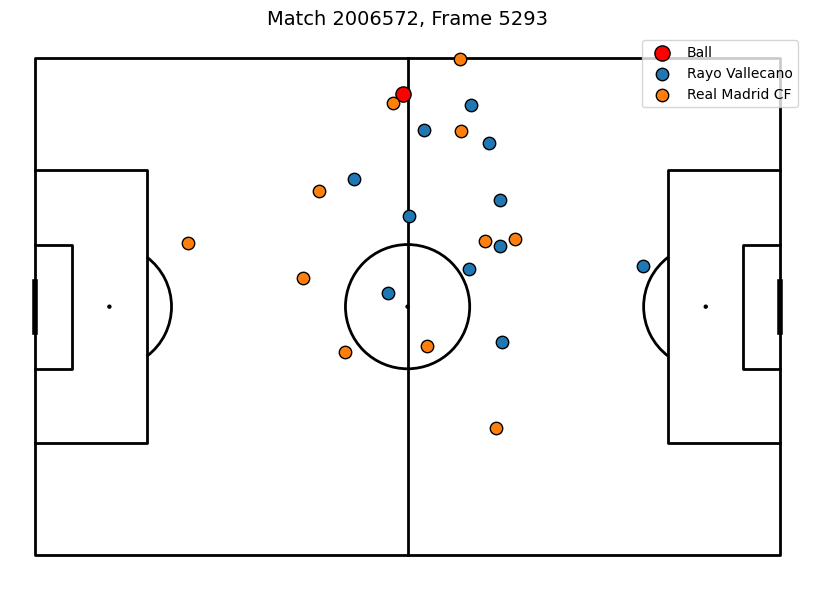

In [19]:

# Pick a random frame
random_row = df_freeze_start_enriched.sample(1).iloc[0]
match_id = random_row["match_id"]
frame_no = random_row["frame"]

frame_example = df_freeze_start_enriched[
    (df_freeze_start_enriched["match_id"] == match_id) &
    (df_freeze_start_enriched["frame"] == frame_no)
]

print(f"Plotting Match {match_id}, Frame {frame_no}")

# Initialize pitch
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9, 6))

# Plot ball
ball = frame_example[frame_example["is_ball"] == True]
ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")

# Plot players by team
for team, group in frame_example[frame_example["is_ball"] == False].groupby("player_team_name"):
    ax.scatter(group["x_rescaled"], group["y_rescaled"], s=80, edgecolors="k", label=team)

# Add title and legend
ax.set_title(f"Match {match_id}, Frame {frame_no}", fontsize=14)
ax.legend()
plt.show()


# Section 12: Defensive Line Detection by Last Outfield Player

## 12.1 Why Defensive Lines?

Defensive line = the line formed by the last outfield defenders (usually center-backs).

Key for:

🏃 Offside detection

📊 Tactical compactness

📏 Measuring defensive block height

## 12.2 Step 1: Detect the Last Defender

For simplicity:

Exclude the goalkeeper (we’ll treat player_id of GK separately if available).

Take the maximum x-coordinate of defenders for the team that is not in possession.

If Team A is defending, last_defender_x = max(defenders’ x).

In [20]:

def plot_defensive_line(frame_df, defending_team_name, defend_left=True):
    """
    Plot players on the pitch and add a dashed line for the last defender
    (2nd deepest player) of the defending_team.

    Parameters
    ----------
    frame_df : pd.DataFrame
        Freeze-frame tracking data for a single frame. Must contain:
        - x_rescaled, y_rescaled (mplsoccer coordinates: 0-105 x 0-68)
        - is_ball (True/False)
        - player_team_name
    defending_team_name : str
        The actual team name (e.g. "Real Madrid CF") to evaluate.
    defend_left : bool, default=True
        If True, team defends the left goal (x close to 0).
        If False, team defends the right goal (x close to 105).
    """
    frame_df = frame_df.copy()
    
    # Defensive players (exclude ball)
    defenders = frame_df[
        (frame_df["player_team_name"] == defending_team_name) & (frame_df["is_ball"] == False)
    ]
    
    if defenders.empty:
        print(f"No defenders found for {defending_team_name} in this frame")
        return
    
    # Sort defenders based on defending direction
    if defend_left:
        sorted_defenders = defenders.sort_values("x_rescaled")  # left side → smallest x
    else:
        sorted_defenders = defenders.sort_values("x_rescaled", ascending=False)  # right side → largest x
    
    # Defensive line = 2nd deepest player
    if len(sorted_defenders) >= 2:
        last_defender_x = sorted_defenders.iloc[1]["x_rescaled"] if defend_left else sorted_defenders.iloc[1]["x_rescaled"]
    else:
        last_defender_x = np.nan
    
    # --- Plotting ---
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9,6))
    
    # Plot ball
    ball = frame_df[frame_df["is_ball"]]
    ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")
    
    # Plot players by team
    for team, group in frame_df.groupby("player_team_name"):
        ax.scatter(group["x_rescaled"], group["y_rescaled"], s=80, alpha=0.9, edgecolors="k", label=team)
    
    # Defensive line
    if not np.isnan(last_defender_x):
        ax.axvline(last_defender_x, color="black", linestyle="--", linewidth=2, label="Defensive line")
    
    ax.set_title(f"Defensive line of {defending_team_name}", fontsize=14)
    ax.legend()
    plt.show()


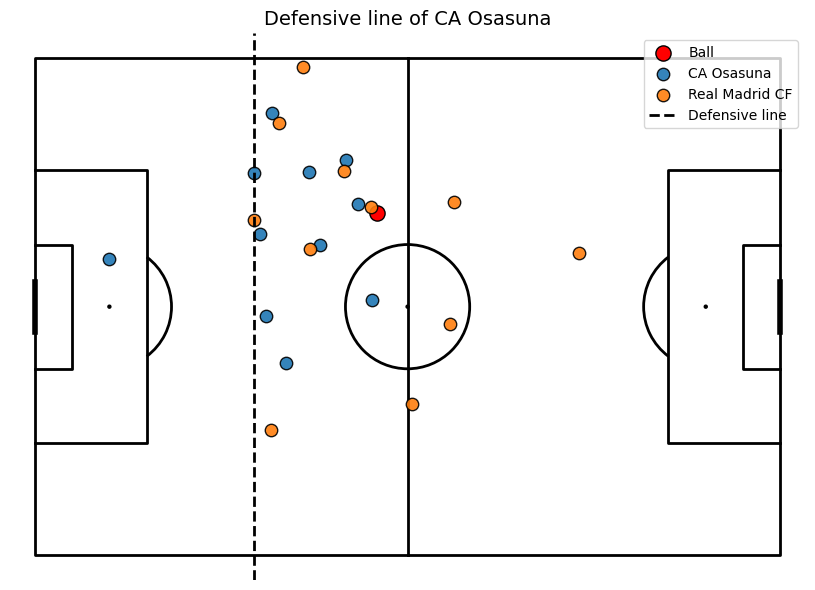

In [21]:
# Pick a random frame
random_row = df_freeze_start_enriched.sample(1).iloc[0]
match_id = random_row["match_id"]
frame_no = random_row["frame"]

frame_example = df_freeze_start_enriched[
    (df_freeze_start_enriched["match_id"] == match_id) &
    (df_freeze_start_enriched["frame"] == frame_no)
]

# Pick defending team from this frame
defending_team = frame_example.loc[~frame_example["is_ball"], "player_team_name"].unique()[0]

# Plot
plot_defensive_line(frame_example, defending_team_name=defending_team, defend_left=True)



# 📚 Section 13: Detecting Defensive Lines with Clustering

isolates Real Madrid’s out-of-possession frames,

normalizes direction so their own goal is always on the left,

trains a single KMeans model (k=3) on all defensive player x-positions, and

applies it back to any frame to draw the three defensive lines.

In [65]:
df_freeze_start_enriched

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1021404,00:00:03.10,41,1,13899,False,False,-38.25,0.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05,13899.0,Unai Simón,273.0,Athletic Club de Bilbao,Athletic Bilbao,Other,Goalkeeper,13.882212,34.84,56.942308,35.05
1,1021404,00:00:03.10,41,1,13903,False,False,-20.35,-5.84,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05,13903.0,Dani Vivian,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Right Center Back,31.954327,28.16,56.942308,35.05
2,1021404,00:00:03.10,41,1,32276,False,False,-20.71,6.49,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05,32276.0,Aitor Paredes,273.0,Athletic Club de Bilbao,Athletic Bilbao,Central Defender,Left Center Back,31.590865,40.49,56.942308,35.05
3,1021404,00:00:03.10,41,1,8259,False,False,-3.64,-19.77,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05,8259.0,Óscar De Marcos,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Right Back,48.825000,14.23,56.942308,35.05
4,1021404,00:00:03.10,41,1,4463,False,False,-16.72,12.00,8_0,41,41,00:03.1,00:03.1,273,left_to_right,4461,Iñaki Williams,Athletic Bilbao,unknown,pass,4.40,1.05,4.4,1.05,4463.0,Íñigo Lekue,273.0,Athletic Club de Bilbao,Athletic Bilbao,Full Back,Left Back,35.619231,46.00,56.942308,35.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2443615,2014987,01:34:51.20,58242,2,698903,True,False,-23.04,-0.70,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81,698903.0,Fer López,285.0,RC Celta de Vigo,Celta Vigo,Wide Attacker,Right Forward,29.238462,33.30,83.091346,47.81
2443616,2014987,01:34:51.20,58242,2,4368,False,False,-18.98,10.09,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81,4368.0,Iago Aspas,285.0,RC Celta de Vigo,Celta Vigo,Wide Attacker,Right Forward,33.337500,44.09,83.091346,47.81
2443617,2014987,01:34:51.20,58242,2,61123,True,False,-35.56,-20.28,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81,61123.0,W. Swedberg,285.0,RC Celta de Vigo,Celta Vigo,Wide Attacker,Left Forward,16.598077,13.72,83.091346,47.81
2443618,2014987,01:34:51.20,58242,2,296080,True,False,-36.21,5.24,8_1152,58232,58242,94:50.2,94:51.2,285,right_to_left,29801,Óscar Mingueza,Celta Vigo,pass_reception,pass,25.33,14.03,30.3,13.81,296080.0,Pablo Durán,285.0,RC Celta de Vigo,Celta Vigo,Center Forward,Center Forward,15.941827,39.24,83.091346,47.81


## Remove gaol keeper

In [22]:
# Remove rows where player_position_group is "Other" or missing
df_filtered = df_freeze_start_enriched[
    df_freeze_start_enriched["player_position_group"].notna() &
    (df_freeze_start_enriched["player_position_group"] != "Other")
].copy()

print("Before filtering:", len(df_freeze_start_enriched))
print("After filtering :", len(df_filtered))
print("Dropped rows    :", len(df_freeze_start_enriched) - len(df_filtered))


Before filtering: 2443620
After filtering : 2124588
Dropped rows    : 319032


In [23]:
# 1️⃣ Filter defensive frames

# We only want Real Madrid players when they are out of possession.


TARGET_TEAM = "Real Madrid"   # adjust if meta uses another name

# Defensive players: Real Madrid, not ball, and not in possession
rm_def_rows = df_filtered[
    (df_filtered["player_team_shortname"] == TARGET_TEAM) &
    (~df_filtered["is_ball"]) &
    (df_filtered["team_id"] != df_filtered["player_team_id"])  # Opponent in possession
].copy()



In [24]:
# 2️⃣ Normalize attack direction

def normalize_own_goal_left(df, target_team="Real Madrid"):
    df = df.copy()
    df["rm_defend_left"] = np.where(
        (df["player_team_name"] == target_team) & (~df["is_ball"]),
        np.where(df["attacking_side"] == "right_to_left", True, False),
        np.nan
    )
    df["rm_defend_left"] = df.groupby(["match_id","frame"])["rm_defend_left"].transform("max")

    df["x_norm"] = np.where(df["rm_defend_left"], df["x_rescaled"], PITCH_LENGTH - df["x_rescaled"])
    df["y_norm"] = np.where(df["rm_defend_left"], df["y_rescaled"], PITCH_WIDTH - df["y_rescaled"])
    return df

rm_def_rows = normalize_own_goal_left(rm_def_rows)

In [25]:
# 3️⃣ Cluster X positions into 3 defensive lines
X_train = rm_def_rows[["x_norm"]].values
kmeans_lines = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_train)
centers = np.sort(kmeans_lines.cluster_centers_.ravel())
print("Cluster centers (depth from own goal):", centers)

Cluster centers (depth from own goal): [25.59192528 52.58588658 80.01596986]


In [26]:
# 4️⃣ Assign line IDs
def assign_defensive_lines_in_frame(frame_df, target_team=TARGET_TEAM, kmeans_model=kmeans_lines):
    df = frame_df.copy()
    mask_def = (df["player_team_shortname"] == target_team) & (~df["is_ball"])
    if mask_def.sum() == 0:
        return df
    df.loc[mask_def, ["x_norm","y_norm"]] = normalize_own_goal_left(df.loc[mask_def])[["x_norm","y_norm"]]
    labels = kmeans_model.predict(df.loc[mask_def, ["x_norm"]].values)
    centers_unsorted = kmeans_model.cluster_centers_.ravel()
    order = np.argsort(centers_unsorted)
    label_to_line = {order[i]: i+1 for i in range(3)}
    df.loc[mask_def, "def_line_id"] = [label_to_line[l] for l in labels]
    return df

rm_def_rows_labeled = assign_defensive_lines_in_frame(rm_def_rows)

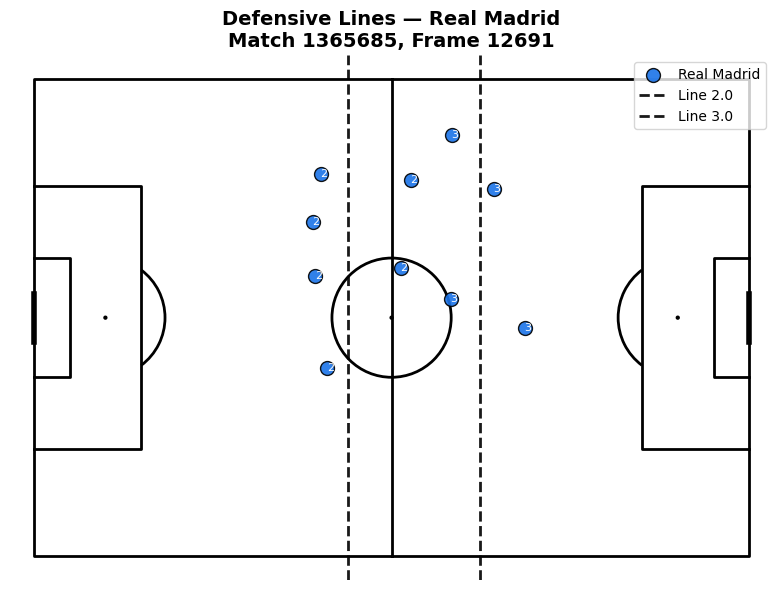

In [27]:
# 1️⃣ Select a random frame for the target team (Real Madrid)
TARGET_TEAM = "Real Madrid"

# Sample one random frame where Real Madrid are defending
frame_id = (
    rm_def_rows_labeled
    .query("player_team_shortname == @TARGET_TEAM")
    .sample(1, random_state=10)["frame"]
    .iloc[0]
)
match_id = (
    rm_def_rows_labeled
    .query("frame == @frame_id")["match_id"]
    .iloc[0]
)

# 2️⃣ Extract all players from that match & frame
frame_example = rm_def_rows_labeled[
    (rm_def_rows_labeled["match_id"] == match_id) &
    (rm_def_rows_labeled["frame"] == frame_id)
].copy()

# 3️⃣ Keep only the defending team (Real Madrid)
frame_example = frame_example[frame_example["player_team_shortname"] == TARGET_TEAM]

# 4️⃣ Plot
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9, 6))

# Ball
ball = rm_def_rows_labeled[
    (rm_def_rows_labeled["match_id"] == match_id) &
    (rm_def_rows_labeled["frame"] == frame_id) &
    (rm_def_rows_labeled["is_ball"])
]
if not ball.empty:
    ax.scatter(ball["x_norm"], ball["y_norm"], c="red", s=120, edgecolors="k", label="Ball")

# Players (Real Madrid defenders)
ax.scatter(frame_example["x_norm"], frame_example["y_norm"],
           s=100, c="#1A73E8", edgecolors="k", alpha=0.9, label=TARGET_TEAM)

# Label defensive line IDs
for _, row in frame_example.iterrows():
    if not pd.isna(row.get("def_line_id")):
        ax.text(row["x_norm"] + 0.5, row["y_norm"], int(row["def_line_id"]),
                fontsize=8, color="white", ha="center", va="center")

# 5️⃣ Compute and draw mean x of each defensive line
line_means = frame_example.groupby("def_line_id")["x_norm"].mean().to_dict()
for line_id, x_mean in line_means.items():
    ax.axvline(x_mean, linestyle="--", linewidth=2, color="black", alpha=0.9, label=f"Line {line_id}")

# 6️⃣ Title and legend
ax.set_title(f"Defensive Lines — {TARGET_TEAM}\nMatch {match_id}, Frame {frame_id}", fontsize=14, weight="bold")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), loc="upper right")

plt.show()


KMeans assumes equal variance clusters, which is fine here (x positions are roughly distinct), but Jenks natural breaks or Gaussian Mixture Models could sometimes produce smoother separations.

If your dataset includes outliers (players sprinting back), consider trimming or winsorizing x values before clustering.

These centers correspond to average depth of:

- Back line (deepest, closest to goal)

- Midfield line

- Most advanced defensive line (attacking line)

# 📊 Season-Wide Defensive Line Stats

Step 1. Compute line depth per match/opponent

We take the mean x_rescaled of each line, grouped by match_id, opponent, and def_line_id.

In [28]:
# Add opponent column
rm_def_rows_labeled["opponent"] = np.where(
    rm_def_rows_labeled["team_shortname"] == rm_def_rows_labeled["player_team_shortname"],
    rm_def_rows_labeled["attacking_side"],  # fallback if needed
    rm_def_rows_labeled["team_shortname"]
)

# Defensive line stats per match & opponent
line_stats = (
    rm_def_rows_labeled
    .groupby(["match_id", "opponent", "def_line_id"])
    ["x_rescaled"]
    .mean()
    .reset_index()
    .rename(columns={"x_rescaled": "avg_depth"})
)

# Step 2. Pivot for clarity

# We want 1 row per match/opponent, with 3 columns = line depths.

line_stats_pivot = (
    line_stats
    .pivot_table(index=["match_id", "opponent"], 
                 columns="def_line_id", 
                 values="avg_depth")
    .reset_index()
    .rename(columns={1: "back_line_depth", 2: "midfield_line_depth", 3: "high_line_depth"})
)

print(line_stats_pivot.head())



def_line_id  match_id         opponent  back_line_depth  midfield_line_depth  high_line_depth
0             1021404  Athletic Bilbao        24.916523            51.935263        79.291078
1             1036527       UD Almería        24.432591            51.649052        80.748560
2             1048195       Celta Vigo        24.974366            52.762628        80.107642
3             1064327        Getafe CF        22.806752            52.999019        80.713584
4             1096879    Real Sociedad        26.007976            53.960153        78.672636


Step 3. Aggregate season-wide summary

You can now look at:

overall averages (season mean),

per opponent (tactical trends),

per match (game-to-game changes).

In [29]:
# Season-wide average defensive line depths
season_avg = line_stats_pivot[["back_line_depth", "midfield_line_depth", "high_line_depth"]].mean()
print("Season-wide average line depths (m from own goal):")
print(season_avg)

# Average by opponent
opponent_avg = (
    line_stats_pivot
    .groupby("opponent")[["back_line_depth", "midfield_line_depth", "high_line_depth"]]
    .mean()
    .sort_values("back_line_depth")
)
opponent_avg.head()


Season-wide average line depths (m from own goal):
def_line_id
back_line_depth        25.546242
midfield_line_depth    52.598717
high_line_depth        79.915352
dtype: float64


def_line_id,back_line_depth,midfield_line_depth,high_line_depth
opponent,,,
FC Union Berlin,23.583779,52.541458,79.828503
Salzbourg,23.589648,52.183173,80.452424
CF Cadiz,23.983872,53.272911,79.879644
UD Almería,24.294386,52.451716,80.914393
Atalanta,24.443881,52.493424,80.595981


Step 4. Visualization (example: boxplots across matches)

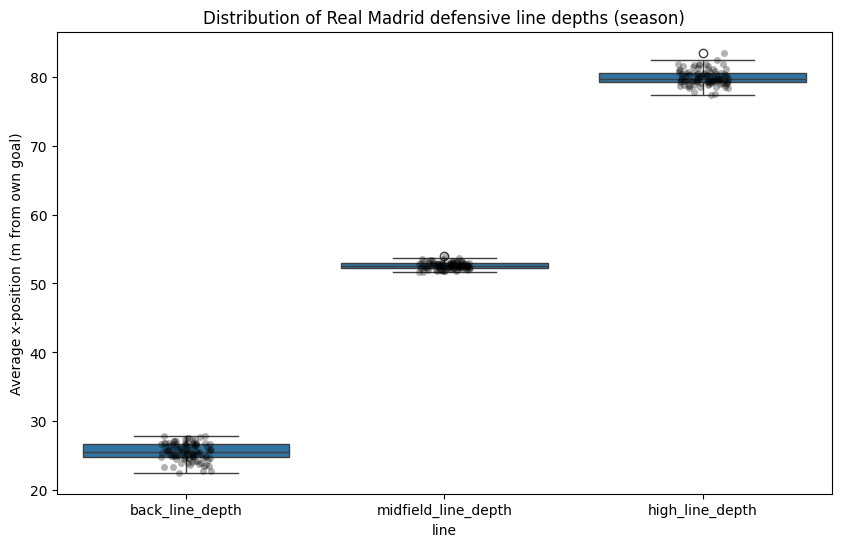

In [30]:

# Melt for plotting
melted = line_stats_pivot.melt(
    id_vars=["match_id", "opponent"], 
    value_vars=["back_line_depth", "midfield_line_depth", "high_line_depth"],
    var_name="line", value_name="depth"
)

plt.figure(figsize=(10,6))
# Plots the distribution of defensive line depths, showing the median, quartiles and outliers
sns.boxplot(data=melted, x="line", y="depth")
# Plots individual points 
sns.stripplot(data=melted, x="line", y="depth", color="black", alpha=0.3)
plt.title("Distribution of Real Madrid defensive line depths (season)")
plt.ylabel("Average x-position (m from own goal)")
plt.show()


# 📏 Adding Compactness Metrics

Step 1. Compute compactness at match level

We already have line_stats_pivot with 3 line depths per match.
Now we add distances between the lines.

In [31]:
line_stats_pivot["back_to_midfield"] = (
    line_stats_pivot["midfield_line_depth"] - line_stats_pivot["back_line_depth"]
)

line_stats_pivot["back_to_high"] = (
    line_stats_pivot["high_line_depth"] - line_stats_pivot["back_line_depth"]
)

line_stats_pivot["midfield_to_high"] = (
    line_stats_pivot["high_line_depth"] - line_stats_pivot["midfield_line_depth"]
)


Step 2. Season-wide averages

In [32]:
compactness_avg = line_stats_pivot[["back_to_midfield", "back_to_high", "midfield_to_high"]].mean()
print("Season-wide compactness (average distance between lines, meters):")
print(compactness_avg)


Season-wide compactness (average distance between lines, meters):
def_line_id
back_to_midfield    27.052475
back_to_high        54.369110
midfield_to_high    27.316635
dtype: float64


Step 3. Opponent-level compactness

In [33]:
opponent_compactness = (
    line_stats_pivot
    .groupby("opponent")[["back_to_midfield", "back_to_high", "midfield_to_high"]]
    .mean()
    .sort_values("back_to_midfield")
)

print(opponent_compactness.head())


def_line_id     back_to_midfield  back_to_high  midfield_to_high
opponent                                                        
Stade Brestois         25.238579     53.043298         27.804719
Liverpool              25.364035     53.535158         28.171123
Bayern Munchen         25.536760     51.421233         25.884473
SC Braga               25.713181     54.125515         28.412334
Leipzig                25.931673     54.277641         28.345969


Step 4. Visualization
Boxplot of compactness distributions

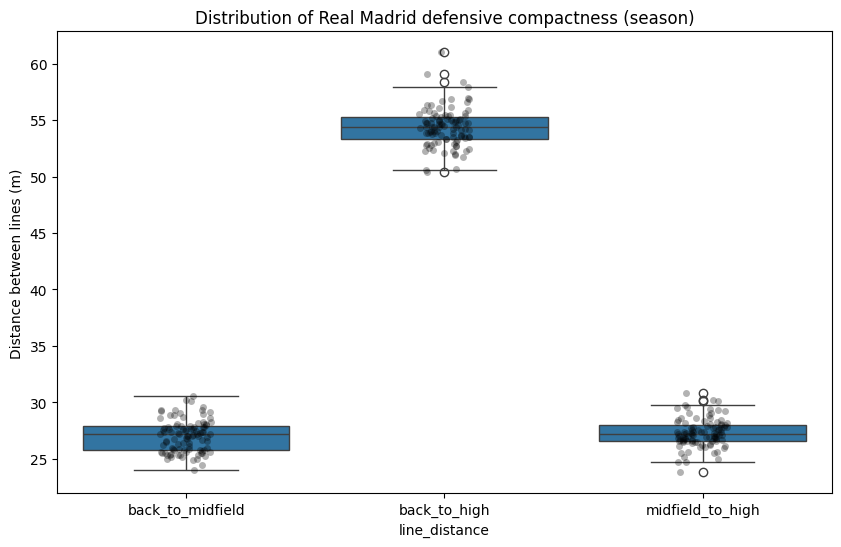

In [34]:
melted_compactness = line_stats_pivot.melt(
    id_vars=["match_id", "opponent"], 
    value_vars=["back_to_midfield", "back_to_high", "midfield_to_high"],
    var_name="line_distance", value_name="meters"
)

plt.figure(figsize=(10,6))
sns.boxplot(data=melted_compactness, x="line_distance", y="meters")
sns.stripplot(data=melted_compactness, x="line_distance", y="meters", color="black", alpha=0.3)
plt.title("Distribution of Real Madrid defensive compactness (season)")
plt.ylabel("Distance between lines (m)")
plt.show()


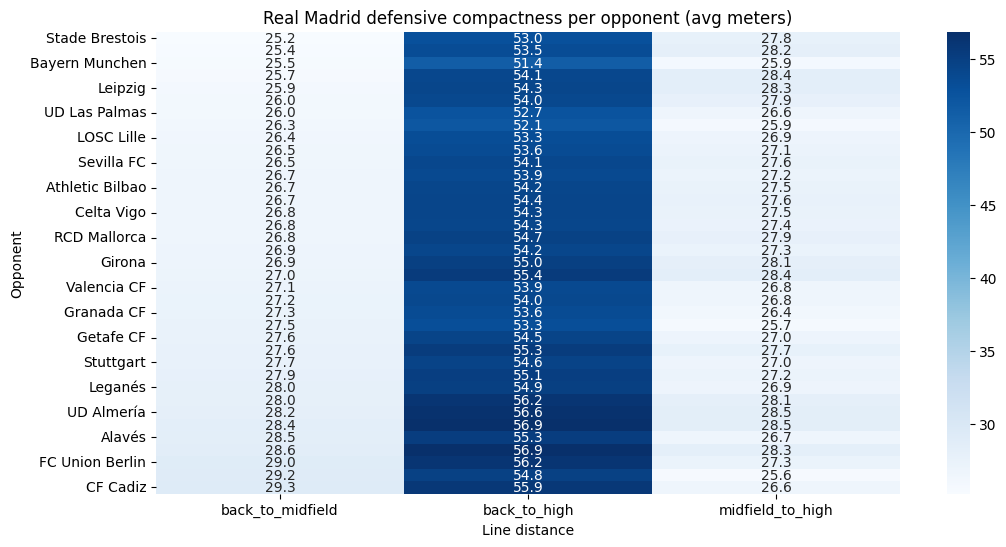

In [35]:
# Average defensive shape per opponent
plt.figure(figsize=(12,6))
sns.heatmap(opponent_compactness, annot=True, fmt=".1f", cmap="Blues")
plt.title("Real Madrid defensive compactness per opponent (avg meters)")
plt.ylabel("Opponent")
plt.xlabel("Line distance")
plt.show()


✅ With this, you can now analyze:

Depth of each defensive line across season.

Compactness between lines (back–midfield, back–high, midfield–high).

Opponent-specific adjustments (e.g., deeper + tighter vs stronger teams, higher + stretched vs weaker ones).

# 🎉 Notebook Complete!

## What You've Learned

In this notebook, you've covered the fundamentals of working with tracking data:

### 1. ✅ Data Loading & Quality
- Loaded tracking data efficiently using **Polars** for memory management
- Checked data quality (missing players, ball detection)
- Understood coordinate systems

### 2. ✅ Coordinate Transformations
- Converted SkillCorner coordinates to FIFA standard (105×68m)
- Inferred and normalized attack direction
- Made data consistent across halves and matches

### 3. ✅ Kinematic Metrics
- Computed player speed and acceleration
- Smoothed ball trajectories
- Analyzed movement patterns

### 4. ✅ Spatial Analysis
- Created convex hulls for team shape
- Built Voronoi diagrams for pitch control
- Visualized team structure

### 5. ✅ Event Synchronization
- Merged tracking data with dynamic events
- Created freeze frames
- Enriched with player metadata

### 6. ✅ Tactical Analysis
- Detected defensive lines using clustering
- Measured team compactness
- Analyzed defensive organization by opponent

## 💾 Memory-Efficient Approach

This notebook successfully processes **99 matches** with **~100M tracking records** using:
- **On-demand loading** with Polars
- **Batch processing** for aggregations
- **Garbage collection** to free memory
- **Smart filtering** to work with subsets

## 🚀 Next Steps

You can now:
1. Apply these techniques to your own datasets
2. Build more advanced tactical metrics
3. Create custom visualizations
4. Train machine learning models

**Happy analyzing! ⚽📊**
